In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

import warnings
from xarray import SerializationWarning
warnings.filterwarnings("ignore", category=SerializationWarning)

In [2]:
params = pd.read_csv('notebooks/scenario_ensemble/sobol_samples.csv')
params

,name,model,aPhi,n,1/m,uf,gamma,UMV,A0_multiplier,m
0,run001,CESM2-WACCM,5.620000e+09,2.94,4.375000,151.6,21179,7.690000e+18,2.050000,0.229
1,run002,CESM2-WACCM,5.620000e+13,3.94,2.375000,276.6,86159,3.140000e+20,0.000021,0.421
2,run003,CESM2-WACCM,5.620000e+15,2.44,1.375000,89.1,42717,1.200000e+18,649.000000,0.727
3,run004,CESM2-WACCM,5.620000e+11,3.44,3.375000,214.1,10501,4.910000e+19,0.006490,0.296
4,run005,CESM2-WACCM,5.620000e+12,2.19,2.875000,120.3,60667,1.240000e+20,11500.000000,0.348
...,...,...,...,...,...,...,...,...,...,...
123,run124,MIROC-ES2L,3.920000e+12,3.54,4.390625,176.0,60006,5.360000e+19,0.002020,0.228
124,run125,MIROC-ES2L,3.920000e+11,2.79,1.890625,144.7,10386,1.350000e+20,11.300000,0.529
125,run126,MIROC-ES2L,3.920000e+15,3.79,3.890625,269.7,42252,3.320000e+18,0.000113,0.257
126,run127,MIROC-ES2L,3.920000e+13,2.29,4.890625,82.2,85220,8.650000e+20,3590.000000,0.204


In [3]:
data = {}
scenarios = ['ssp126', 'ssp534-over', 'ssp585']
for scenario in scenarios:
    ds = xr.open_dataset(f'/Users/jonniebarnsley/Downloads/sle_{scenario}_clean.nc')
    ds = ds.sum(dim="basin", skipna=False)
    #ds = ds.sel(run=(ds.run != 120))
    data[scenario] = ds['sle']

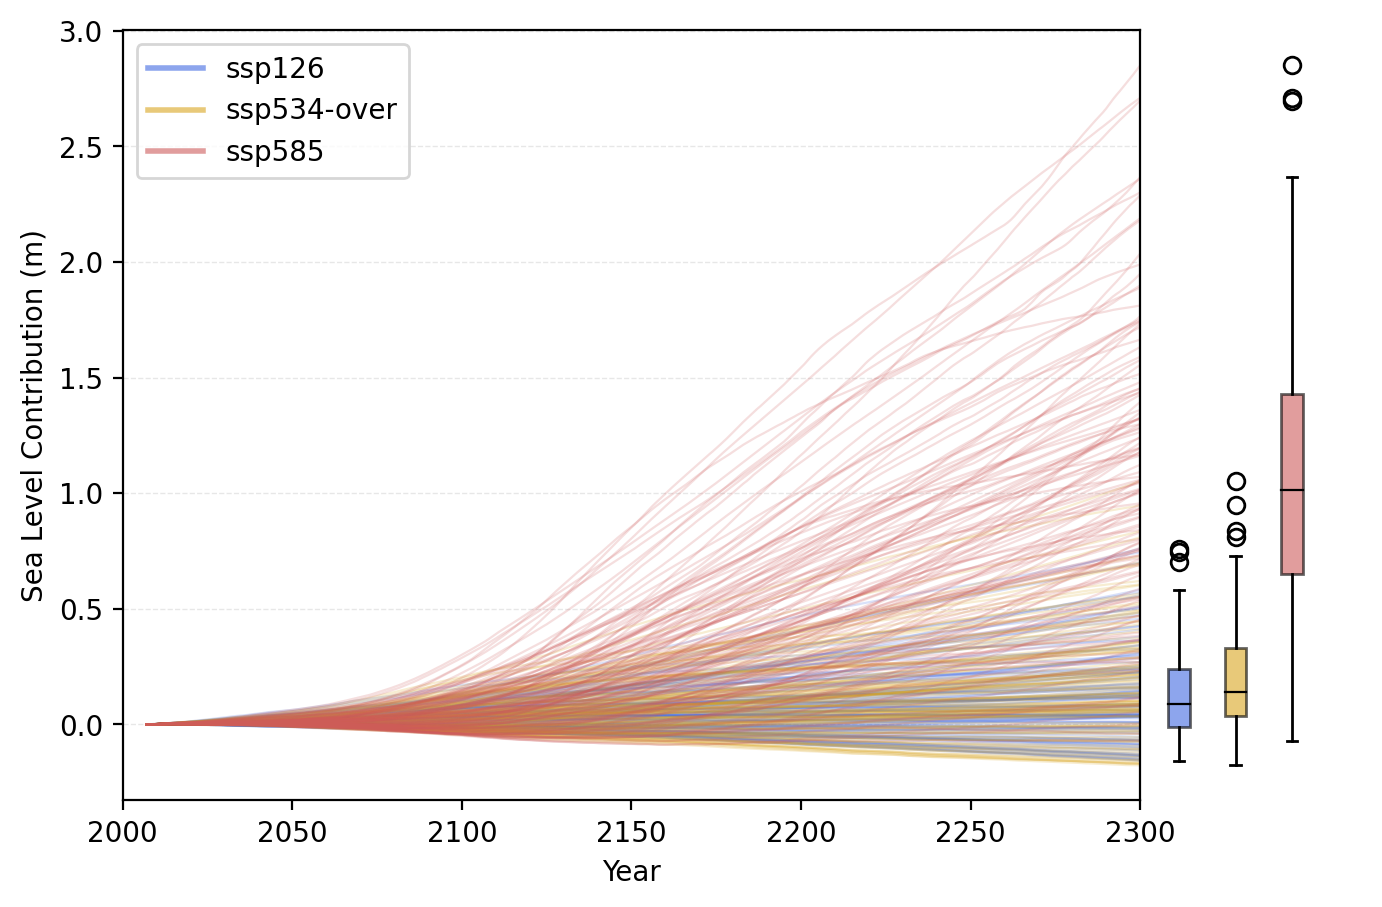

In [14]:
from matplotlib.lines import Line2D
fig = plt.figure(figsize=(8, 5), dpi=200)
gs = fig.add_gridspec(ncols=2, width_ratios=[4, 1], wspace=-0.05)

ax_ts = fig.add_subplot(gs[0])
ax_box = fig.add_subplot(gs[1], sharey=ax_ts)

colors = {'ssp126': 'royalblue', 'ssp534-over': 'goldenrod', 'ssp585': 'indianred'}
legend_handles = []
for scenario, sle in data.items():
    for run in sle.run:
        ax_ts.plot(sle.time, sle.sel(run=run), color=colors[scenario], alpha=0.2, lw=0.8)
    legend_handles.append(
        Line2D([0], [0], color=colors[scenario], lw=2, label=scenario, alpha=0.6)
    )


ax_ts.set_xlabel('Year')
ax_ts.set_ylabel('Sea Level Contribution (m)')
ax_ts.set_xlim(2000, 2300)

box_data = []
labels = []
for scenario, sle in data.items():
    final_sle = sle.isel(time=-1).values
    final_sle = final_sle[~np.isnan(final_sle)]
    box_data.append(final_sle)
    labels.append(scenario)

positions = np.arange(len(box_data)) * 0.4 + 1
bp = ax_box.boxplot(box_data, positions=positions, vert=True, patch_artist=True, widths=0.15, showfliers=True)
for patch, color in zip(bp['boxes'], colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
for median in bp["medians"]:
    median.set_color("black")   # or any color you like
    median.set_linewidth(0.8)     # optional, make it thicker


ax_box.set_axis_off()
ax_ts.legend(
    handles=legend_handles,
    loc="upper left",
    frameon=True
)

ax_ts.grid(visible=True, which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.3)

plt.savefig('/Users/jonniebarnsley/Downloads/scenario_slc.svg', format='svg', bbox_inches='tight', dpi=300)

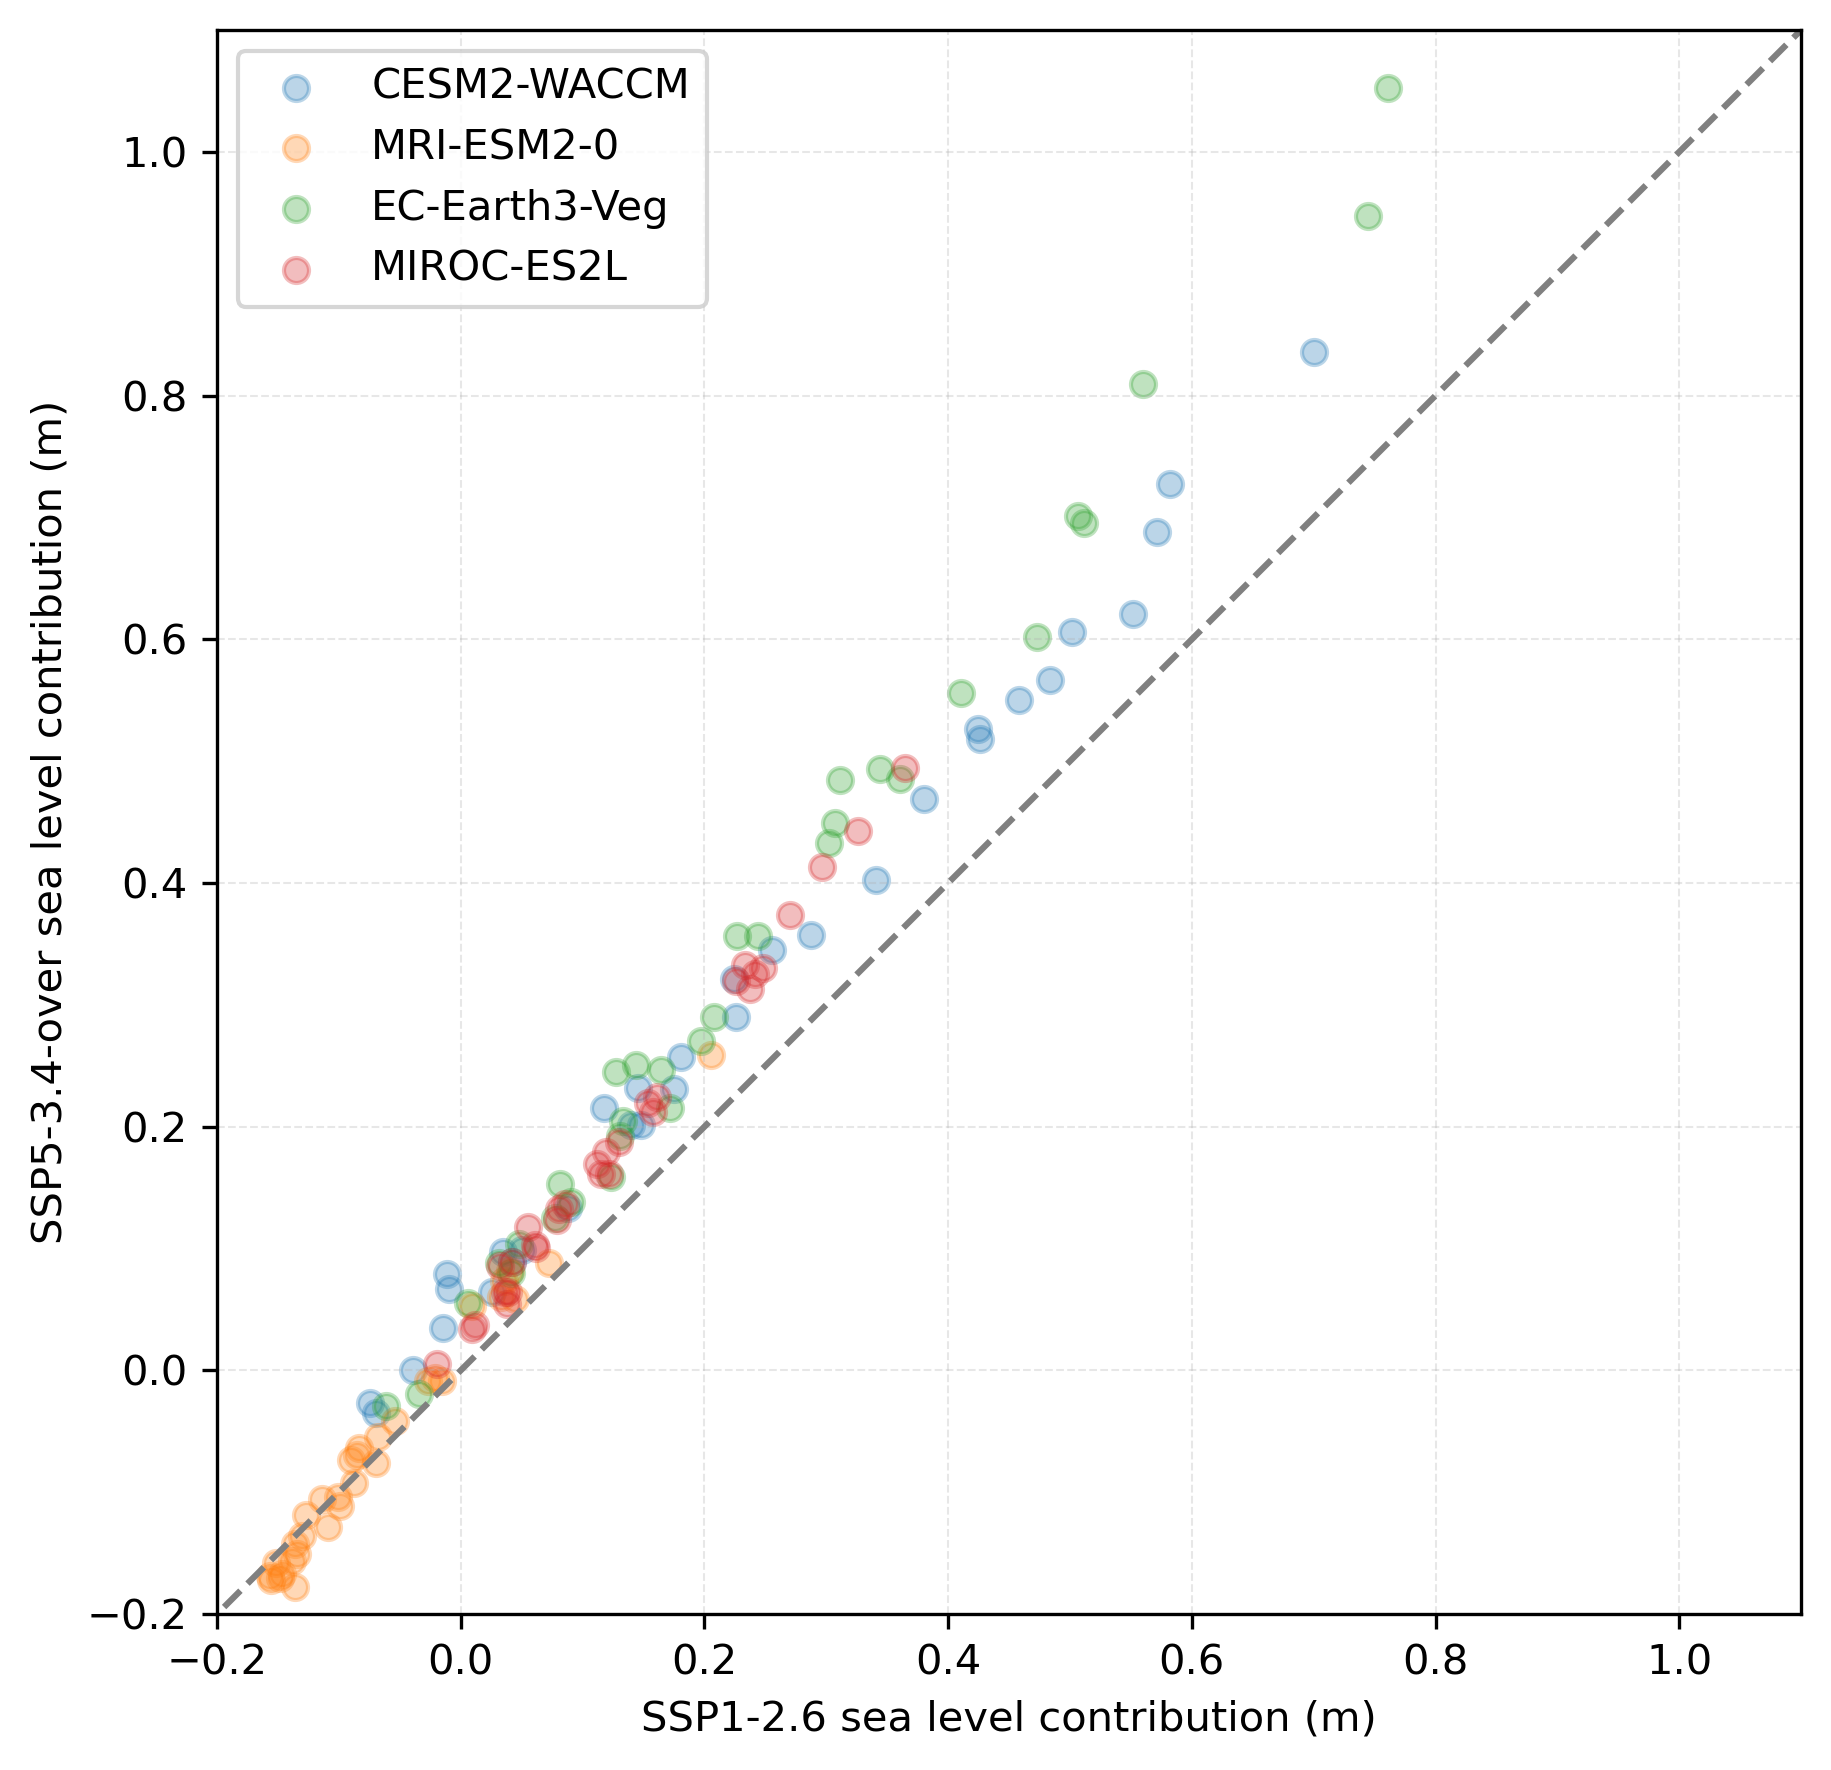

In [12]:
final_126 = data['ssp126'].isel(time=-1).values
final_534 = data['ssp534-over'].isel(time=-1).values
final_585 = data['ssp585'].isel(time=-1).values

models = ['CESM2-WACCM', 'MRI-ESM2-0', 'EC-Earth3-Veg', 'MIROC-ES2L']
num_model = 16
plt.figure(dpi=300)
for j, i in enumerate(range(0, 64, num_model)):
    p126 = np.concatenate([final_126[i:i+num_model], final_126[i+64:i+64+num_model]])
    p534 = np.concatenate([final_534[i:i+num_model], final_534[i+64:i+64+num_model]])
    plt.scatter(p126, p534, alpha=0.3, label=models[j % 4])
x = np.linspace(-1, 2, 100)
plt.plot(x, x, color='grey', linestyle='--')
plt.xlim(-0.2, 1.1)
plt.ylim(-0.2, 1.1)
plt.xlabel('SSP1-2.6 sea level contribution (m)')
plt.ylabel('SSP5-3.4-over sea level contribution (m)')
plt.grid(visible=True, which='both', axis='both', linestyle='--', linewidth=0.5, alpha=0.3)
plt.gcf().set_size_inches(8, 6)
plt.legend()
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.savefig("/Users/jonniebarnsley/Downloads/ssp126_vs_534.svg", format='svg', dpi=300, bbox_inches='tight')

In [6]:
diff = final_534 - final_126
diff = diff[~np.isnan(diff)]
print(f'mean: {diff.mean()}')
print(f'std: {diff.std()}')
print(f'max: {max(diff)}')
print(f'min: {min(diff)}')

mean: 0.06229627551021853
std: 0.05480980946208532
max: 0.2916495630440358
min: -0.04182063720853463


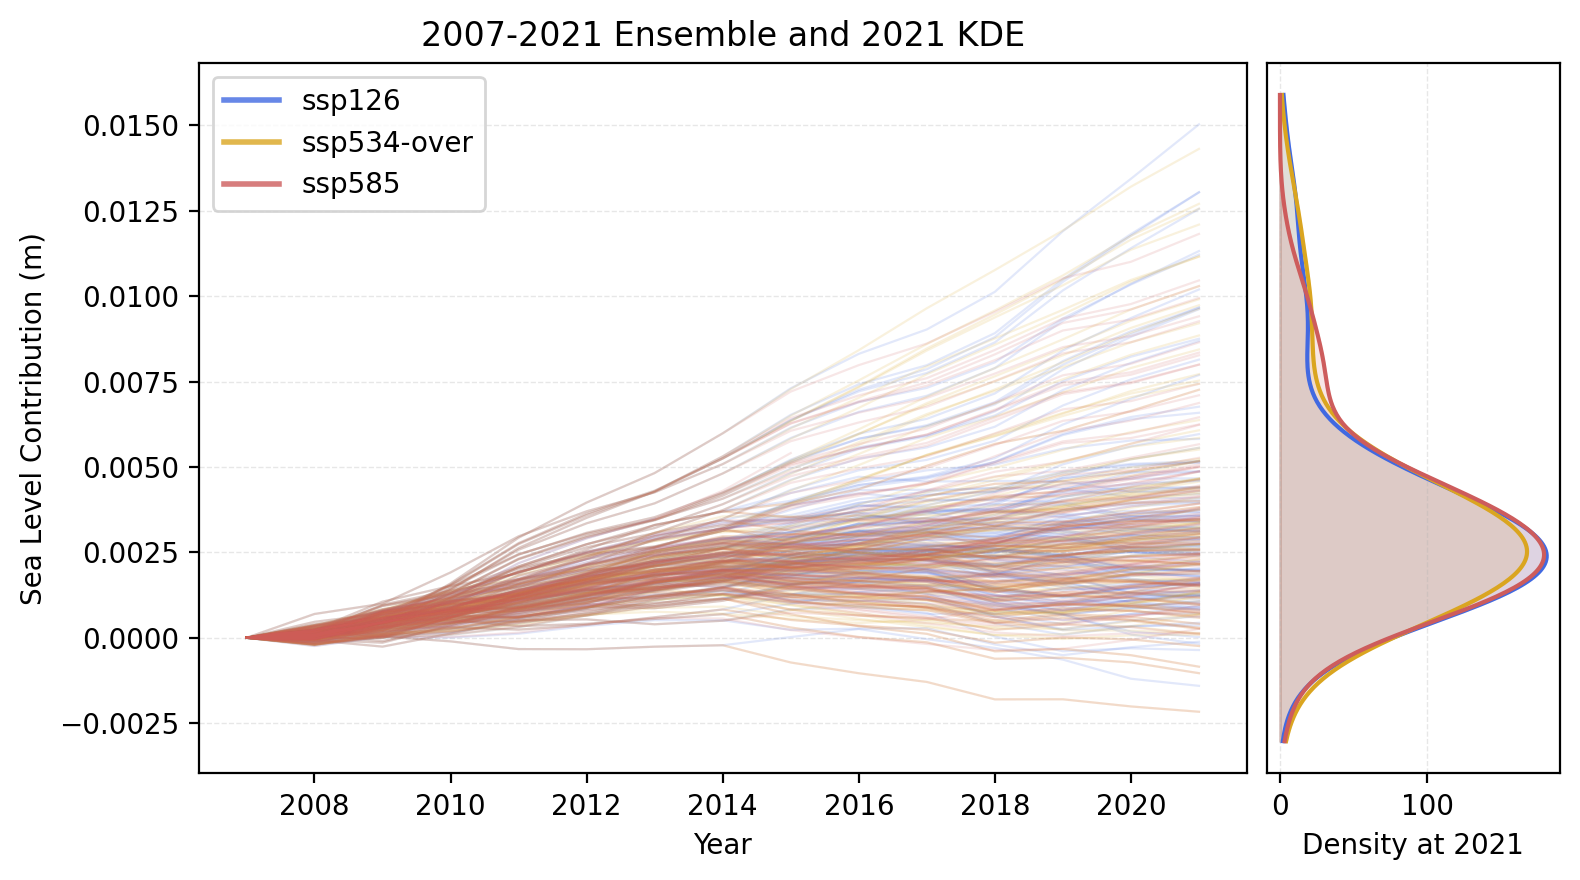

In [16]:
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable

IMBIE = {
    "AIS": (5.28e-3, 0.51e-3),
    "EAIS": (-0.03e-3, 0.43e-3),
    "WAIS": (4.63e-3, 0.25e-3),
    "APIS": (0.69e-3, 0.12e-3)
}

def gaussian_kde_1d(samples, y_grid, bandwidth=None):
    samples = np.asarray(samples, dtype=float)
    samples = samples[~np.isnan(samples)]
    n = samples.size
    if n < 2:
        return np.zeros_like(y_grid)

    if bandwidth is None:
        std = samples.std(ddof=1)
        bandwidth = 1.06 * std * (n ** (-1 / 5))
        if (not np.isfinite(bandwidth)) or (bandwidth <= 0):
            bandwidth = max(std, 1e-6)

    u = (y_grid[:, None] - samples[None, :]) / bandwidth
    density = np.exp(-0.5 * u**2).sum(axis=1)
    density /= n * bandwidth * np.sqrt(2 * np.pi)
    return density

fig, ax_ts = plt.subplots(figsize=(8, 4.5), dpi=200)
divider = make_axes_locatable(ax_ts)
ax_kde = divider.append_axes("right", size="28%", pad=0.1, sharey=ax_ts)

scenario_2021 = {}
legend_handles = []

for scenario, sle in data.items():
    obs_window = sle.sel(time=slice(2007, 2021))
    for run in obs_window.run:
        ax_ts.plot(obs_window.time, obs_window.sel(run=run), color=colors[scenario], alpha=0.15, lw=0.8)

    values_2021 = obs_window.sel(time=2021).values.astype(float).ravel()
    values_2021 = values_2021[~np.isnan(values_2021)]
    scenario_2021[scenario] = values_2021

    legend_handles.append(
        Line2D([0], [0], color=colors[scenario], lw=2, label=scenario, alpha=0.8)
    )

ax_ts.set_xlabel("Year")
ax_ts.set_ylabel("Sea Level Contribution (m)")
ax_ts.set_title("2007-2021 Ensemble and 2021 KDE")
ax_ts.grid(visible=True, which="both", axis="y", linestyle="--", linewidth=0.5, alpha=0.3)
ax_ts.legend(handles=legend_handles, loc="upper left", frameon=True)

y0, y1 = ax_ts.get_ylim()
y_min, y_max = sorted((y0, y1))
y_grid = np.linspace(y_min, y_max, 300)

for scenario, values_2021 in scenario_2021.items():
    if values_2021.size < 2:
        continue
    density = gaussian_kde_1d(values_2021, y_grid)
    ax_kde.plot(density, y_grid, color=colors[scenario], lw=1.5)
    ax_kde.fill_betweenx(y_grid, 0, density, color=colors[scenario], alpha=0.15)

ax_kde.set_xlabel("Density at 2021")
ax_kde.grid(visible=True, which="both", axis="x", linestyle="--", linewidth=0.5, alpha=0.3)
ax_kde.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False)

plt.tight_layout()

In [8]:
EAIS = {}
scenarios = ['ssp126', 'ssp534-over', 'ssp585']
for scenario in scenarios:
    ds = xr.open_dataset(f'/Users/jonniebarnsley/Downloads/sle_{scenario}_clean.nc')
    ds = ds.sel(basin=slice(2, 17)).sum(dim="basin", skipna=False)
    #ds = ds.sel(run=(ds.run != 120))
    EAIS[scenario] = ds['sle']

WAIS = {}
for scenario in scenarios:
    ds = xr.open_dataset(f'/Users/jonniebarnsley/Downloads/sle_{scenario}_clean.nc')
    ds = ds.sel(basin=slice(18, 23)).sum(dim="basin", skipna=False) + ds.sel(basin=1)
    #ds = ds.sel(run=(ds.run != 120))
    WAIS[scenario] = ds['sle']

APIS = {}
for scenario in scenarios:
    ds = xr.open_dataset(f'/Users/jonniebarnsley/Downloads/sle_{scenario}_clean.nc')
    ds = ds.sel(basin=slice(24, 27)).sum(dim="basin", skipna=False)
    #ds = ds.sel(run=(ds.run != 120))
    APIS[scenario] = ds['sle']

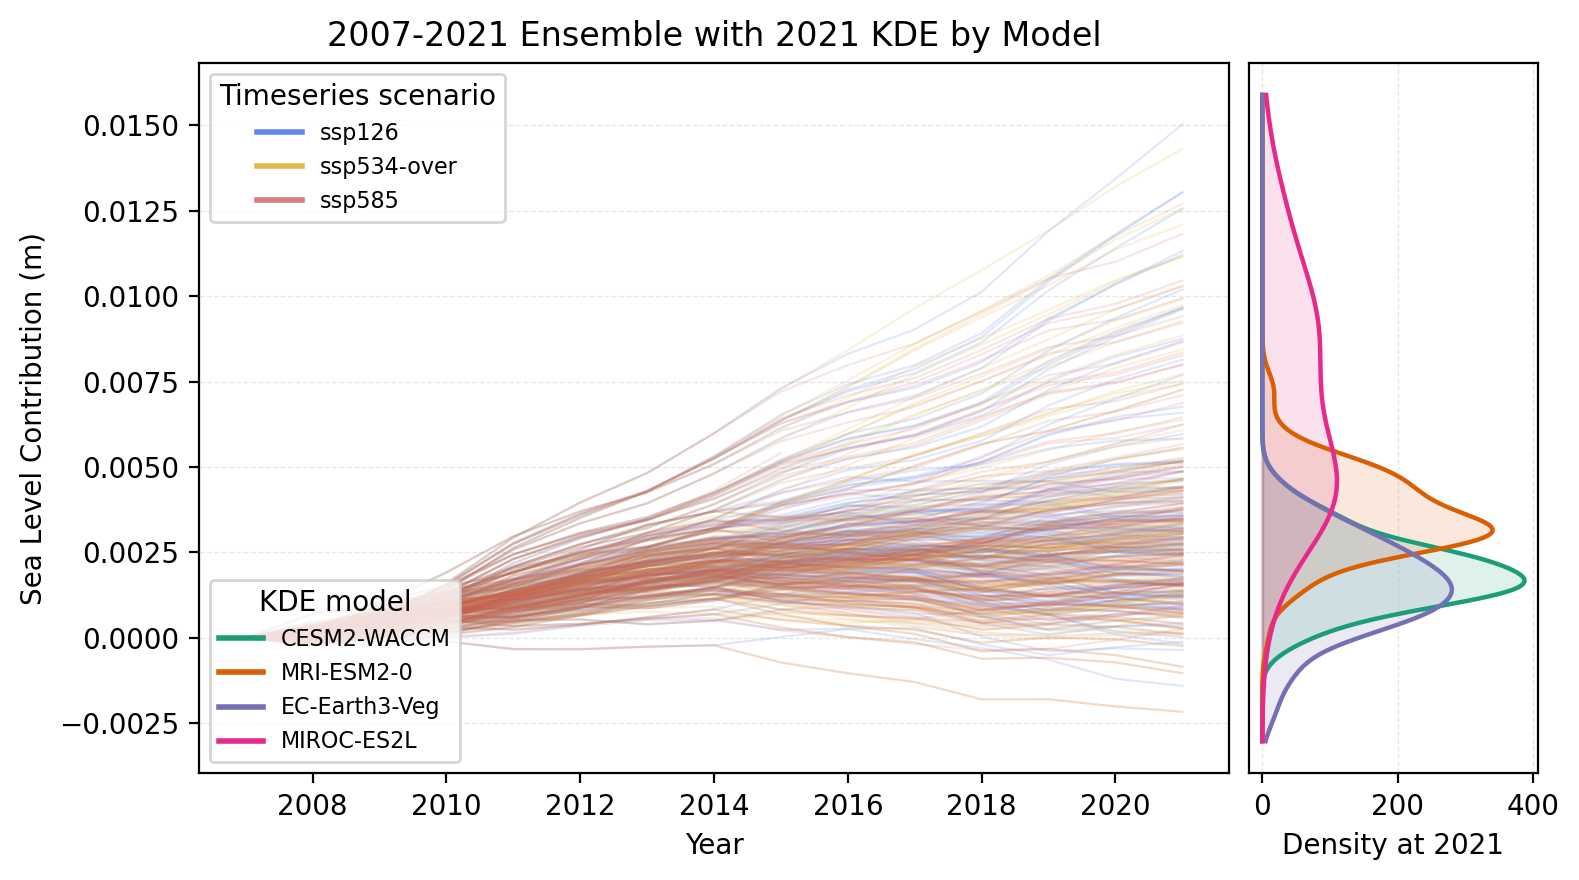

In [18]:
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable

def gaussian_kde_1d(samples, y_grid, bandwidth=None):
    samples = np.asarray(samples, dtype=float)
    samples = samples[~np.isnan(samples)]
    n = samples.size
    if n < 2:
        return np.zeros_like(y_grid)

    if bandwidth is None:
        std = samples.std(ddof=1)
        bandwidth = 1.06 * std * (n ** (-1 / 5))
        if (not np.isfinite(bandwidth)) or (bandwidth <= 0):
            bandwidth = max(std, 1e-6)

    u = (y_grid[:, None] - samples[None, :]) / bandwidth
    density = np.exp(-0.5 * u**2).sum(axis=1)
    density /= n * bandwidth * np.sqrt(2 * np.pi)
    return density

# Repeating run-to-model mapping within each block of 64 runs
model_order = ['CESM2-WACCM', 'MRI-ESM2-0', 'EC-Earth3-Veg', 'MIROC-ES2L']
model_colors = {
    'CESM2-WACCM': '#1b9e77',
    'MRI-ESM2-0': '#d95f02',
    'EC-Earth3-Veg': '#7570b3',
    'MIROC-ES2L': '#e7298a'
}

fig, ax_ts = plt.subplots(figsize=(8, 4.5), dpi=200)
divider = make_axes_locatable(ax_ts)
ax_kde = divider.append_axes('right', size='28%', pad=0.1, sharey=ax_ts)

# Left panel: same 2007-2021 timeseries by scenario
for scenario, sle in data.items():
    obs_window = sle.sel(time=slice(2007, 2021))
    for run in obs_window.run:
        ax_ts.plot(obs_window.time, obs_window.sel(run=run), color=colors[scenario], alpha=0.15, lw=0.8)

ax_ts.set_xlabel('Year')
ax_ts.set_ylabel('Sea Level Contribution (m)')
ax_ts.set_title('2007-2021 Ensemble with 2021 KDE by Model')
ax_ts.grid(visible=True, which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.3)

scenario_handles = [
    Line2D([0], [0], color=colors[s], lw=2, label=s, alpha=0.8)
    for s in data.keys()
]
model_handles = [
    Line2D([0], [0], color=model_colors[m], lw=2, label=m)
    for m in model_order
]

legend1 = ax_ts.legend(handles=scenario_handles, title='Timeseries scenario', loc='upper left', frameon=True, fontsize=8)
ax_ts.add_artist(legend1)
ax_ts.legend(handles=model_handles, title='KDE model', loc='lower left', frameon=True, fontsize=8)

# Right panel: KDE of 2021 values split by model index pattern
model_values = {m: [] for m in model_order}
for scenario, sle in data.items():
    values_2021 = sle.sel(time=2021).values.astype(float).ravel()
    for idx, val in enumerate(values_2021):
        if np.isnan(val):
            continue
        phase = idx % 64
        model_idx = phase // 16
        model_name = model_order[model_idx]
        model_values[model_name].append(val)

y0, y1 = ax_ts.get_ylim()
y_min, y_max = sorted((y0, y1))
y_grid = np.linspace(y_min, y_max, 300)

for model_name in model_order:
    values = np.asarray(model_values[model_name], dtype=float)
    if values.size < 2:
        continue
    density = gaussian_kde_1d(values, y_grid)
    ax_kde.plot(density, y_grid, color=model_colors[model_name], lw=1.6)
    ax_kde.fill_betweenx(y_grid, 0, density, color=model_colors[model_name], alpha=0.14)

ax_kde.set_xlabel('Density at 2021')
ax_kde.grid(visible=True, which='both', axis='x', linestyle='--', linewidth=0.5, alpha=0.3)
ax_kde.tick_params(axis='y', left=False, right=False, labelleft=False, labelright=False)

plt.tight_layout()

/var/folders/d9/3tqzv4xj1sx00nng1hd597500000gn/T/ipykernel_40279/3967137607.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


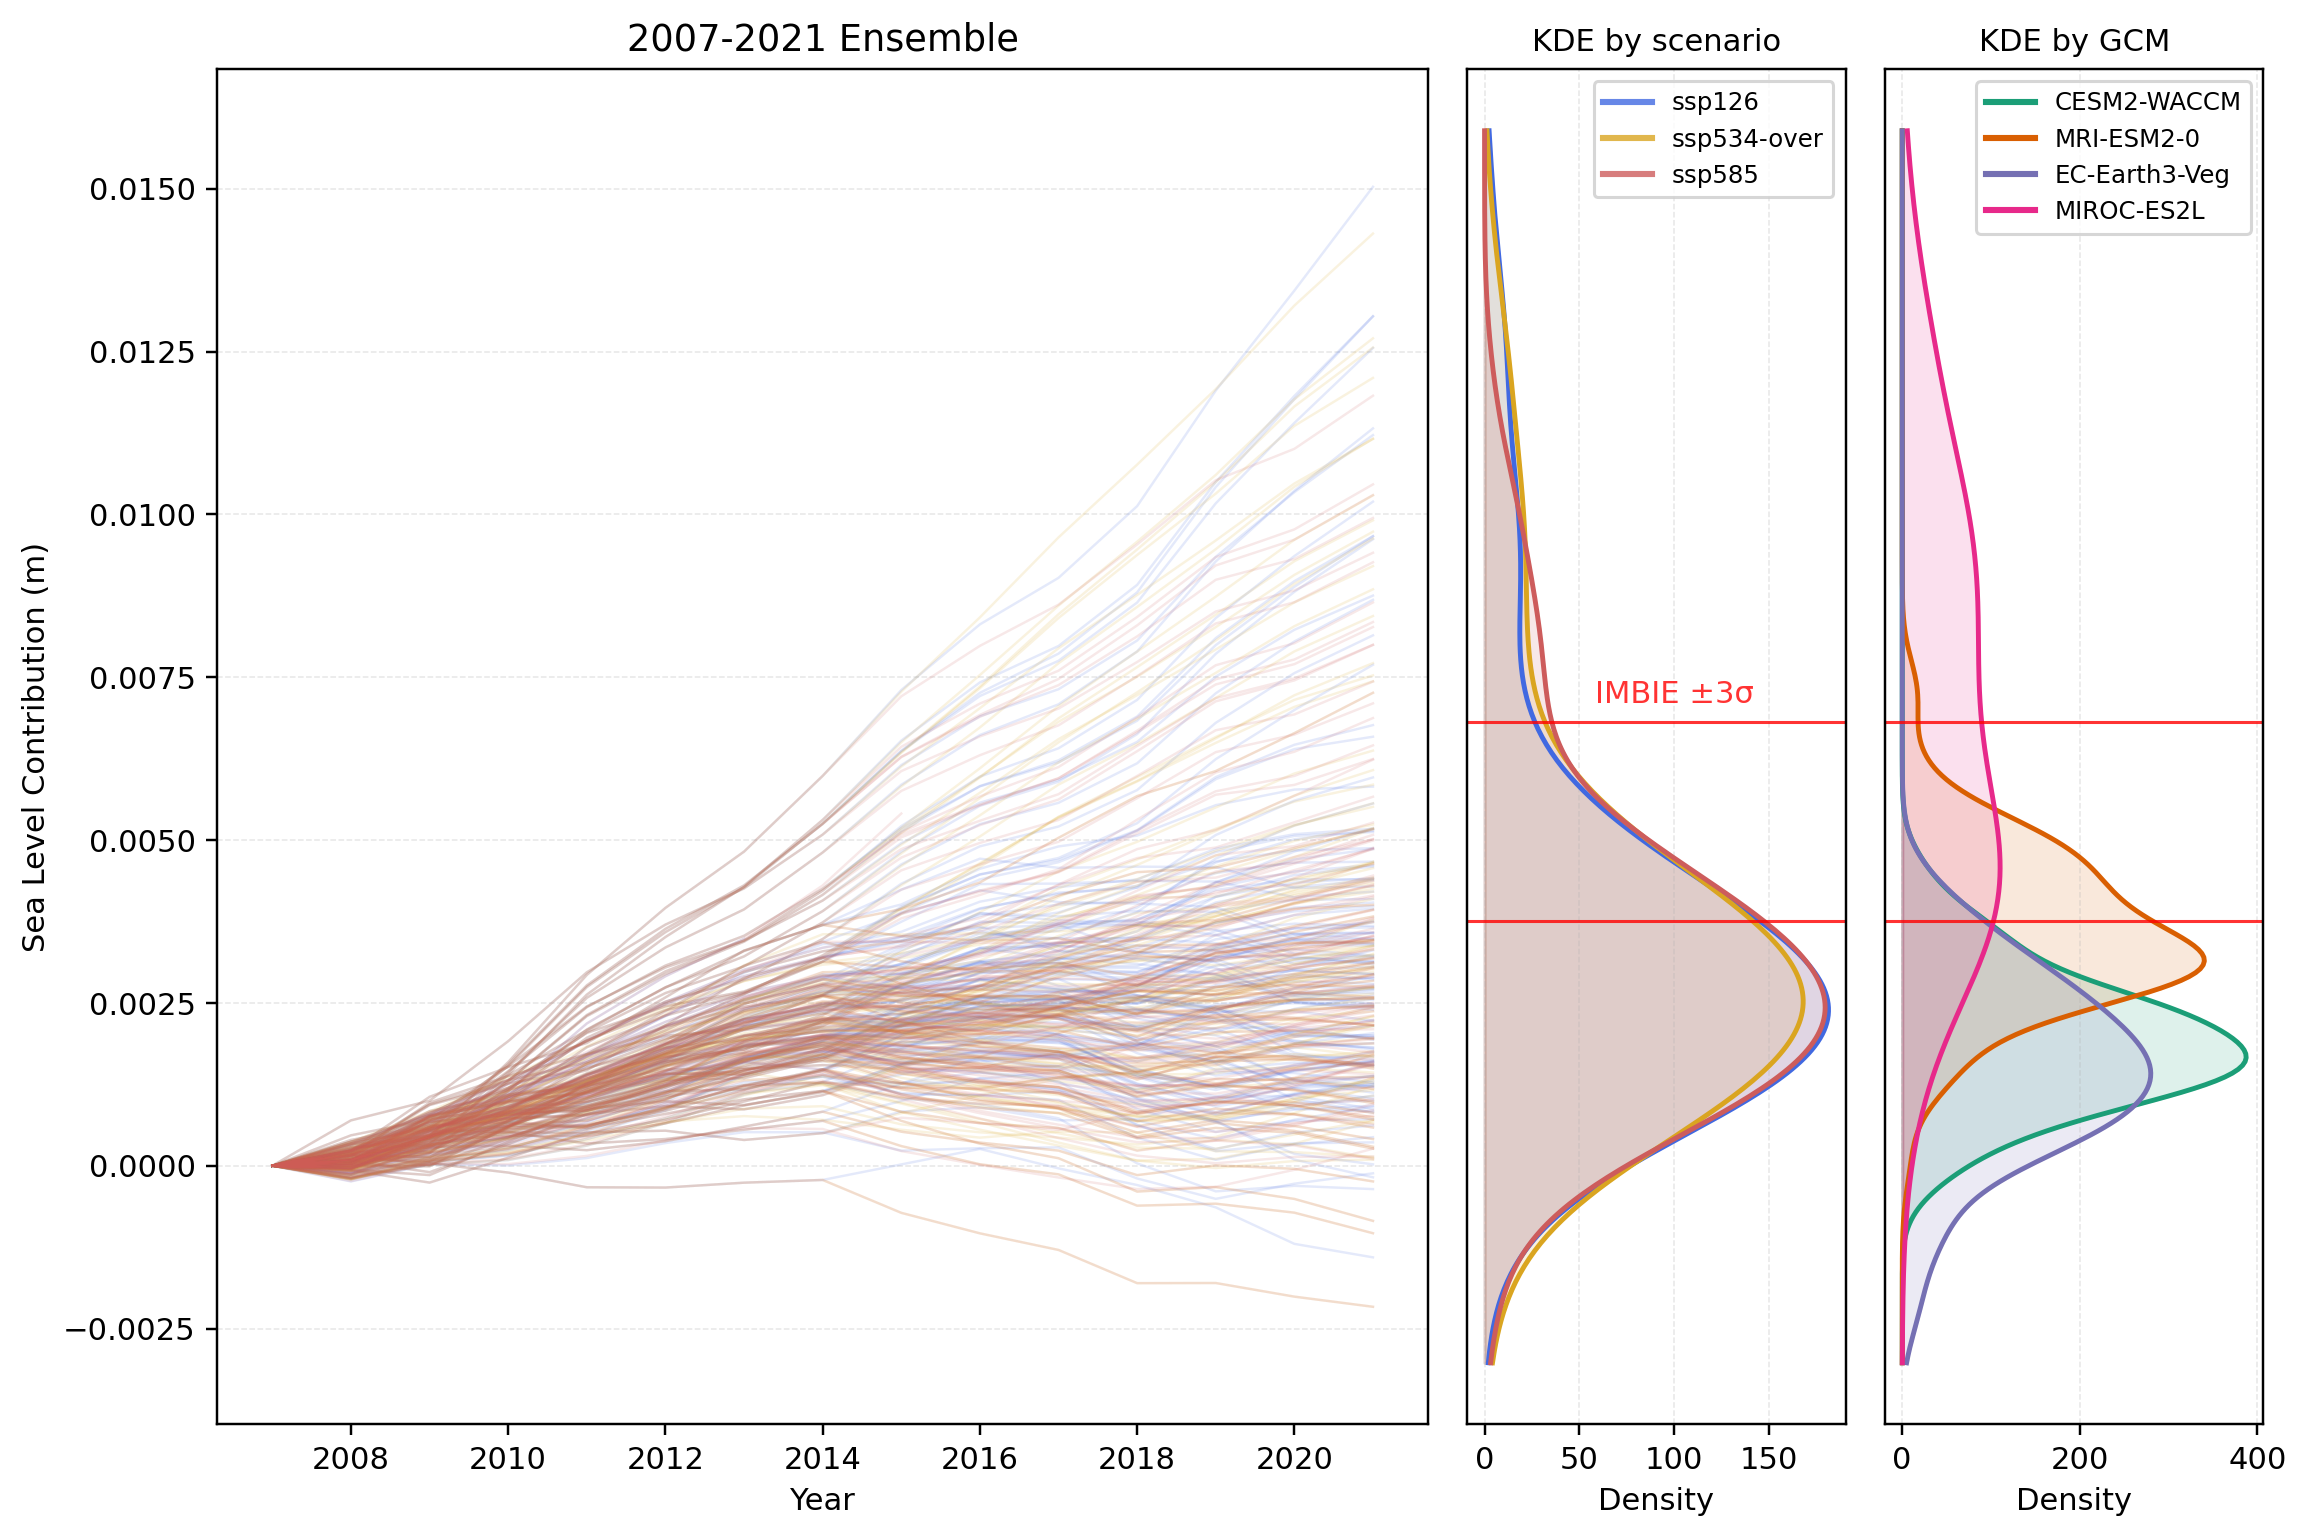

In [45]:
from matplotlib.lines import Line2D

def gaussian_kde_1d(samples, y_grid, bandwidth=None):
    samples = np.asarray(samples, dtype=float)
    samples = samples[~np.isnan(samples)]
    n = samples.size
    if n < 2:
        return np.zeros_like(y_grid)

    if bandwidth is None:
        std = samples.std(ddof=1)
        bandwidth = 1.06 * std * (n ** (-1 / 5))
        if (not np.isfinite(bandwidth)) or (bandwidth <= 0):
            bandwidth = max(std, 1e-6)

    u = (y_grid[:, None] - samples[None, :]) / bandwidth
    density = np.exp(-0.5 * u**2).sum(axis=1)
    density /= n * bandwidth * np.sqrt(2 * np.pi)
    return density

model_order = ['CESM2-WACCM', 'MRI-ESM2-0', 'EC-Earth3-Veg', 'MIROC-ES2L']
model_colors = {
    'CESM2-WACCM': '#1b9e77',
    'MRI-ESM2-0': '#d95f02',
    'EC-Earth3-Veg': '#7570b3',
    'MIROC-ES2L': '#e7298a'
}

fig = plt.figure(figsize=(12, 8), dpi=220)
gs = fig.add_gridspec(ncols=3, width_ratios=[4, 1.25, 1.25], wspace=0.06)
ax_ts = fig.add_subplot(gs[0])
ax_kde_scenario = fig.add_subplot(gs[1], sharey=ax_ts)
ax_kde_model = fig.add_subplot(gs[2], sharey=ax_ts)

scenario_2021 = {}
for scenario, sle in data.items():
    obs_window = sle.sel(time=slice(2007, 2021))
    for run in obs_window.run:
        ax_ts.plot(obs_window.time, obs_window.sel(run=run), color=colors[scenario], alpha=0.14, lw=0.8)

    values_2021 = obs_window.sel(time=2021).values.astype(float).ravel()
    scenario_2021[scenario] = values_2021[~np.isnan(values_2021)]

ax_ts.set_xlabel('Year')
ax_ts.set_ylabel('Sea Level Contribution (m)')
ax_ts.set_title('2007-2021 Ensemble')
ax_ts.grid(visible=True, which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.3)

scenario_handles = [
    Line2D([0], [0], color=colors[s], lw=2, label=s, alpha=0.8)
    for s in data.keys()
]
#ax_ts.legend(handles=scenario_handles, title='Timeseries scenario', loc='upper left', frameon=True, fontsize=8)

y0, y1 = ax_ts.get_ylim()
y_min, y_max = sorted((y0, y1))
y_grid = np.linspace(y_min, y_max, 320)

for scenario, values in scenario_2021.items():
    if values.size < 2:
        continue
    density = gaussian_kde_1d(values, y_grid)
    ax_kde_scenario.plot(density, y_grid, color=colors[scenario], lw=1.6)
    ax_kde_scenario.fill_betweenx(y_grid, 0, density, color=colors[scenario], alpha=0.14)

ax_kde_scenario.legend(handles=scenario_handles, loc='upper right', frameon=True, fontsize=8)
ax_kde_scenario.set_title('KDE by scenario', fontsize=10)
ax_kde_scenario.set_xlabel('Density')
ax_kde_scenario.grid(visible=True, which='both', axis='x', linestyle='--', linewidth=0.5, alpha=0.3)
ax_kde_scenario.tick_params(axis='y', left=False, right=False, labelleft=False, labelright=False)

# add imbie bounds
imbie_mean, imbie_std = IMBIE['AIS']
lo = imbie_mean - 3 * imbie_std
hi = imbie_mean + 3 * imbie_std
ax_kde_scenario.axhline(lo, color='red', linestyle='-', lw=1, alpha=0.8, label='IMBIE')
ax_kde_scenario.axhline(hi, color='red', linestyle='-', lw=1, alpha=0.8)
ax_kde_scenario.text(100, hi+0.0002, 'IMBIE ±3σ', color='red', fontsize=10, alpha=0.8, \
                     ha='center', va='bottom', transform=ax_kde_scenario.transData)

model_values = {m: [] for m in model_order}
for scenario, sle in data.items():
    values_2021 = sle.sel(time=2021).values.astype(float).ravel()
    for idx, val in enumerate(values_2021):
        if np.isnan(val):
            continue
        phase = idx % 64
        model_name = model_order[phase // 16]
        model_values[model_name].append(val)

for model_name in model_order:
    values = np.asarray(model_values[model_name], dtype=float)
    if values.size < 2:
        continue
    density = gaussian_kde_1d(values, y_grid)
    ax_kde_model.plot(density, y_grid, color=model_colors[model_name], lw=1.6)
    ax_kde_model.fill_betweenx(y_grid, 0, density, color=model_colors[model_name], alpha=0.14)

model_handles = [
    Line2D([0], [0], color=model_colors[m], lw=2, label=m)
    for m in model_order
]
ax_kde_model.legend(handles=model_handles, loc='upper right', frameon=True, fontsize=8)
ax_kde_model.set_title('KDE by GCM', fontsize=10)
ax_kde_model.set_xlabel('Density')
ax_kde_model.grid(visible=True, which='both', axis='x', linestyle='--', linewidth=0.5, alpha=0.3)
ax_kde_model.tick_params(axis='y', left=False, right=False, labelleft=False, labelright=False)

ax_kde_model.axhline(lo, color='red', linestyle='-', lw=1, label='IMBIE', alpha=0.8)
ax_kde_model.axhline(hi, color='red', linestyle='-', lw=1, alpha=0.8)

plt.tight_layout()
plt.savefig("/Users/jonniebarnsley/Downloads/ensemble_kde.svg", format='svg', dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'EAIS')

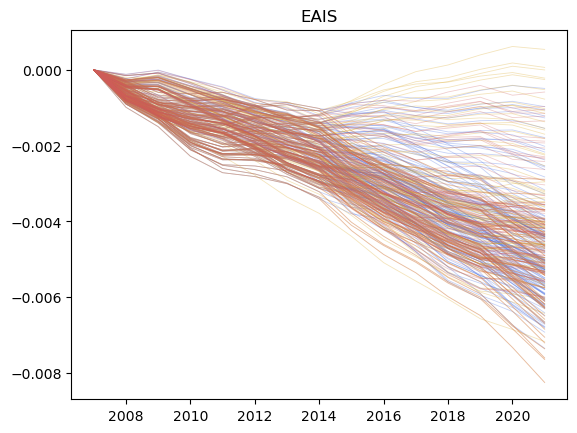

In [9]:
for scenario, sle in EAIS.items():
    sle = sle.sel(time=slice(2007, 2021))
    for run in sle.run:
        plt.plot(sle.time, sle.sel(run=run), color=colors[scenario], alpha=0.3, lw=0.6)
plt.title('EAIS')

Text(0.5, 1.0, 'WAIS')

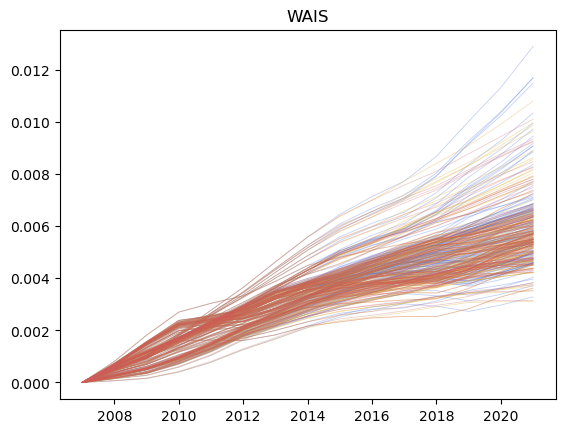

In [10]:
for scenario, sle in WAIS.items():
    sle = sle.sel(time=slice(2007, 2021))
    for run in sle.run:
        plt.plot(sle.time, sle.sel(run=run), color=colors[scenario], alpha=0.3, lw=0.6)
plt.title('WAIS')

Text(0.5, 1.0, 'APIS')

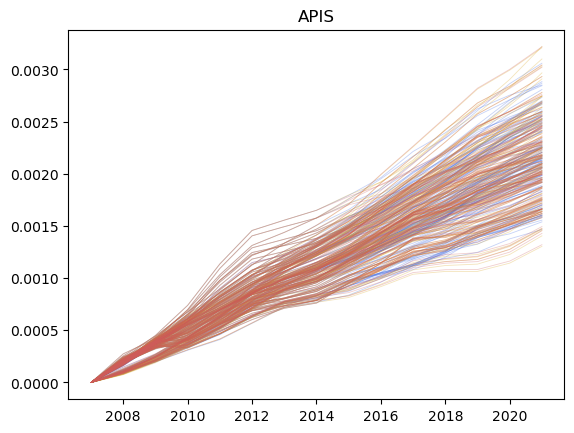

In [11]:
for scenario, sle in APIS.items():
    sle = sle.sel(time=slice(2007, 2021))
    for run in sle.run:
        plt.plot(sle.time, sle.sel(run=run), color=colors[scenario], alpha=0.3, lw=0.6)
plt.title('APIS')

In [12]:
def obs_period_sle(data) -> np.array:
    modelled_sle = np.array([])
    for _, sle in data.items():
        sle_2021 = sle.sel(time=2021)
        modelled_sle = np.concatenate([modelled_sle, sle_2021.values])
    return modelled_sle

IMBIE = {
    "AIS": (5.28e-3, 0.51e-3),
    "EAIS": (-0.03e-3, 0.43e-3),
    "WAIS": (4.63e-3, 0.25e-3),
    "APIS": (0.69e-3, 0.12e-3)
}

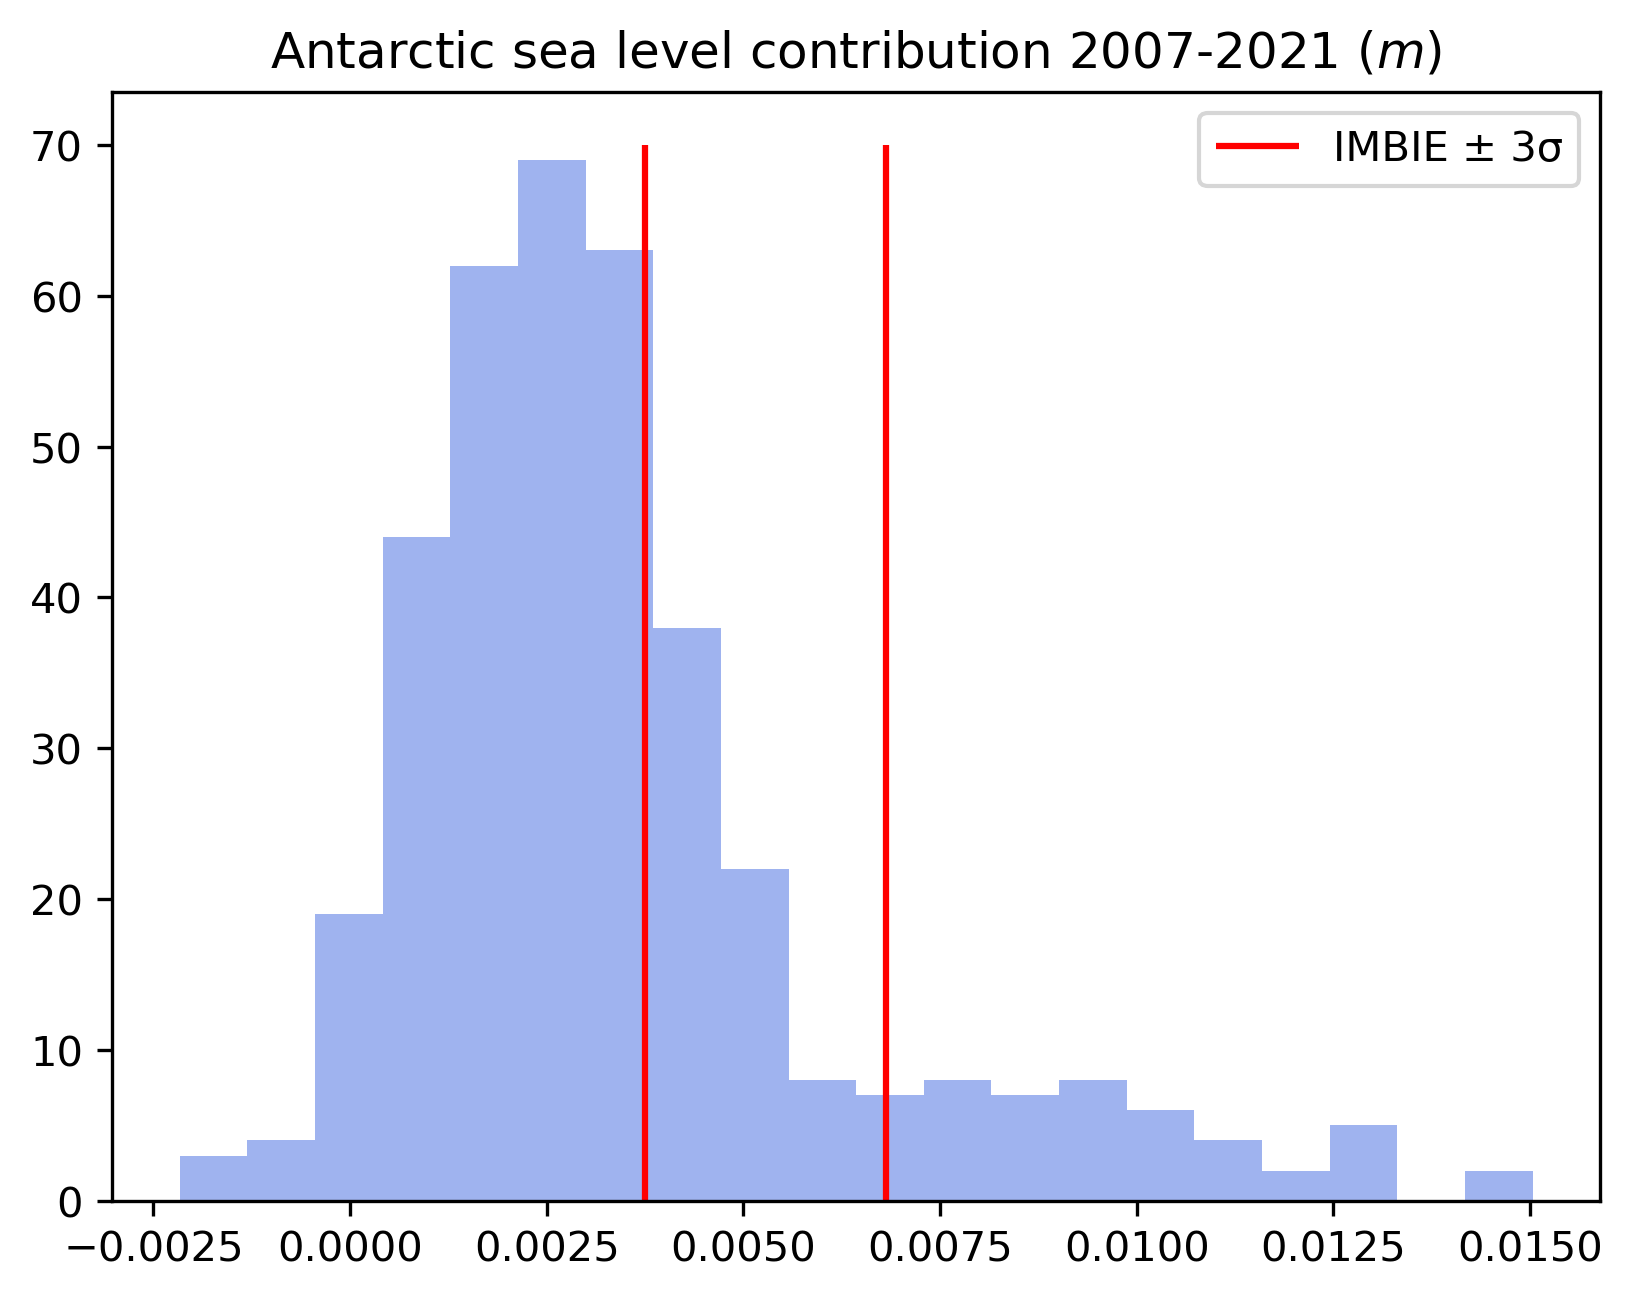

In [19]:
plt.figure(dpi=300)
plt.hist(obs_period_sle(data), bins=20, alpha=0.5, color='royalblue')
mean, sd = IMBIE["AIS"]
LB = mean - 3 * sd
UB = mean + 3 * sd
plt.vlines(LB, ymin=0, ymax=70, color="red")
plt.vlines(UB, ymin=0, ymax=70, color="red", label="IMBIE ± 3σ")
plt.title("Antarctic sea level contribution 2007-2021 ($m$)")
plt.legend()

Text(0.5, 1.0, 'EAIS')

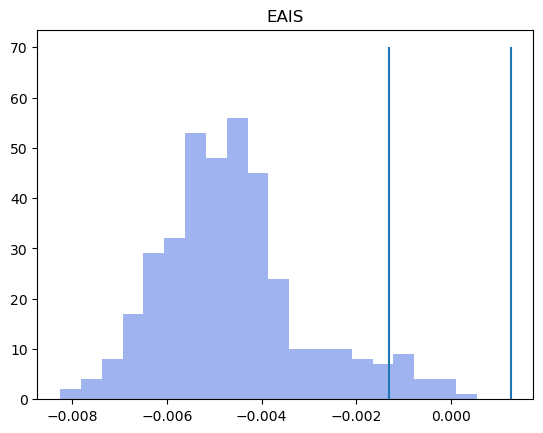

In [246]:
plt.hist(obs_period_sle(EAIS), bins=20, alpha=0.5, color='royalblue')
mean, sd = IMBIE["EAIS"]
LB = mean - 3 * sd
UB = mean + 3 * sd
plt.vlines(LB, ymin=0, ymax=70)
plt.vlines(UB, ymin=0, ymax=70)
plt.title("EAIS")

Text(0.5, 1.0, 'WAIS')

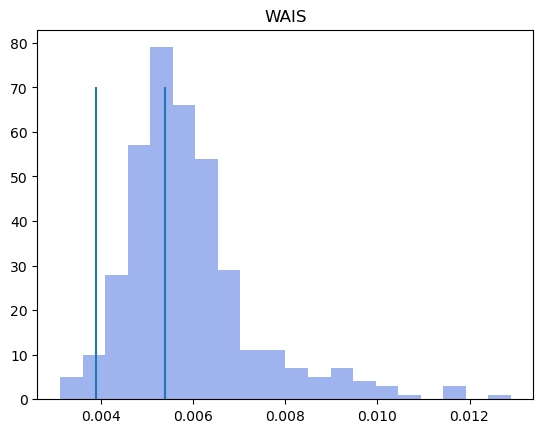

In [247]:
plt.hist(obs_period_sle(WAIS), bins=20, alpha=0.5, color='royalblue')
mean, sd = IMBIE["WAIS"]
LB = mean - 3 * sd
UB = mean + 3 * sd
plt.vlines(LB, ymin=0, ymax=70)
plt.vlines(UB, ymin=0, ymax=70)
plt.title("WAIS")

Text(0.5, 1.0, 'APIS')

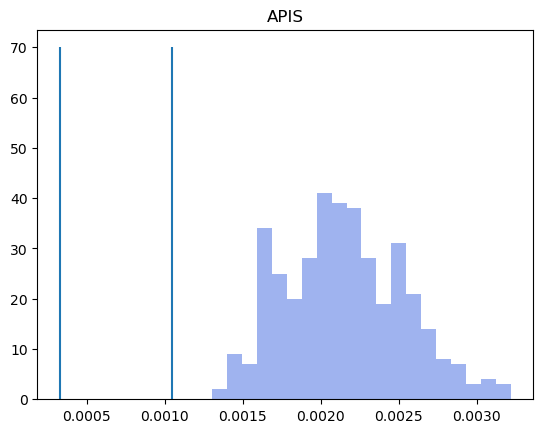

In [248]:
plt.hist(obs_period_sle(APIS), bins=20, alpha=0.5, color='royalblue')
mean, sd = IMBIE["APIS"]
LB = mean - 3 * sd
UB = mean + 3 * sd
plt.vlines(LB, ymin=0, ymax=70)
plt.vlines(UB, ymin=0, ymax=70)
plt.title("APIS")

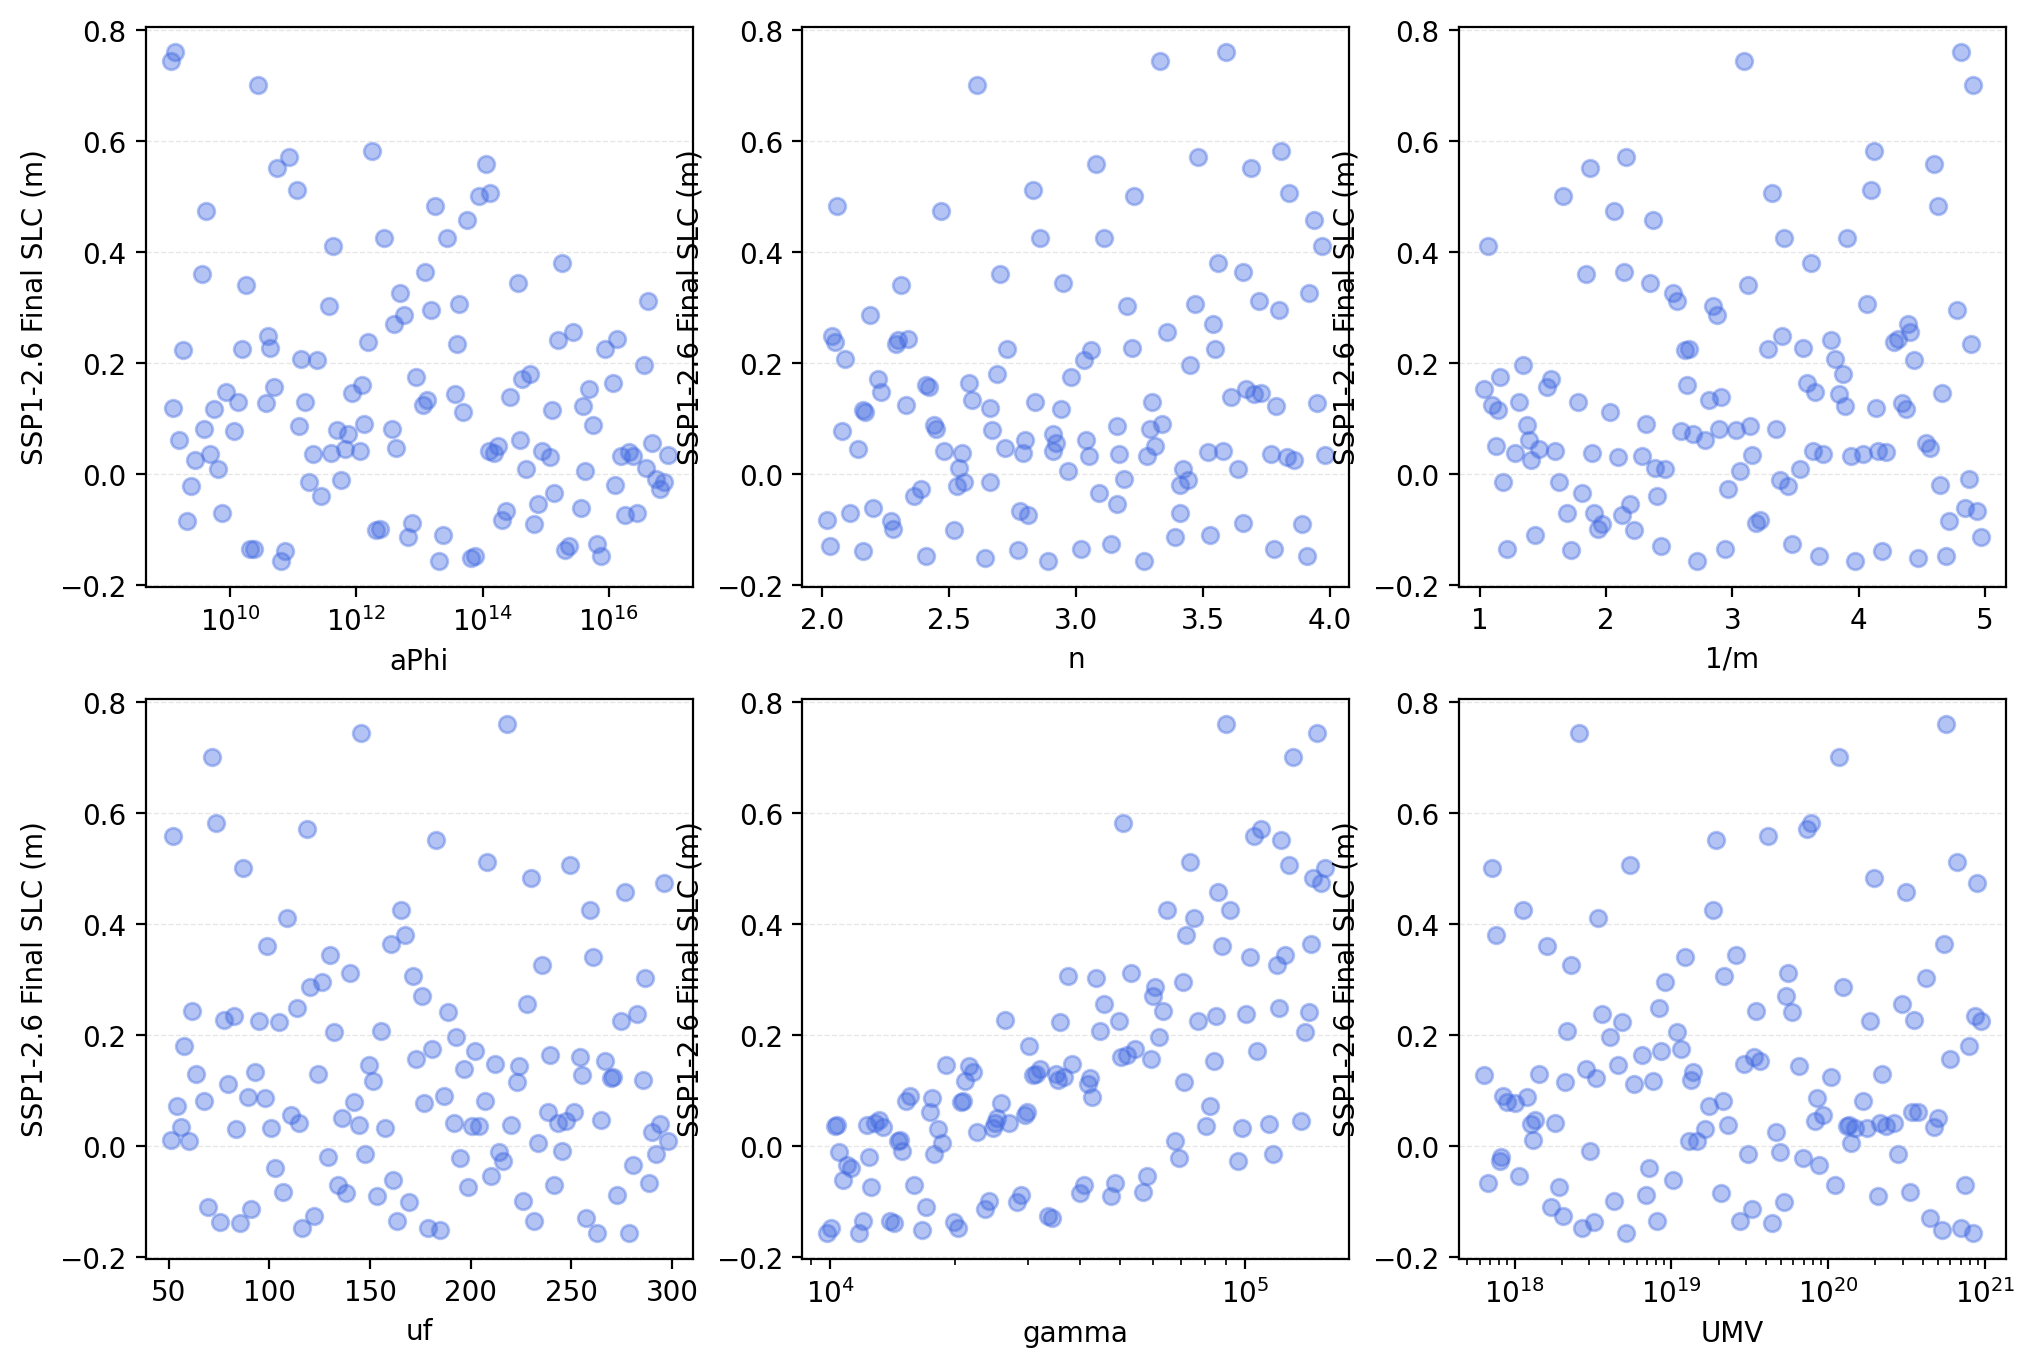

In [53]:
p_names = ['aPhi', 'n', '1/m', 'uf', 'gamma', 'UMV']
scenario = final_126
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8), dpi=200)
axes = axes.flatten()
for i, p_name in enumerate(p_names):
    ax = axes[i]
    p_values = params[p_name].values
    ax.scatter(p_values, scenario, alpha=0.4, color='royalblue')
    ax.set_xlabel(p_name)
    ax.set_ylabel('SSP1-2.6 Final SLC (m)')
    ax.grid(visible=True, which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.3)

for i in [0, 4, 5]:
    axes[i].set_xscale('log')

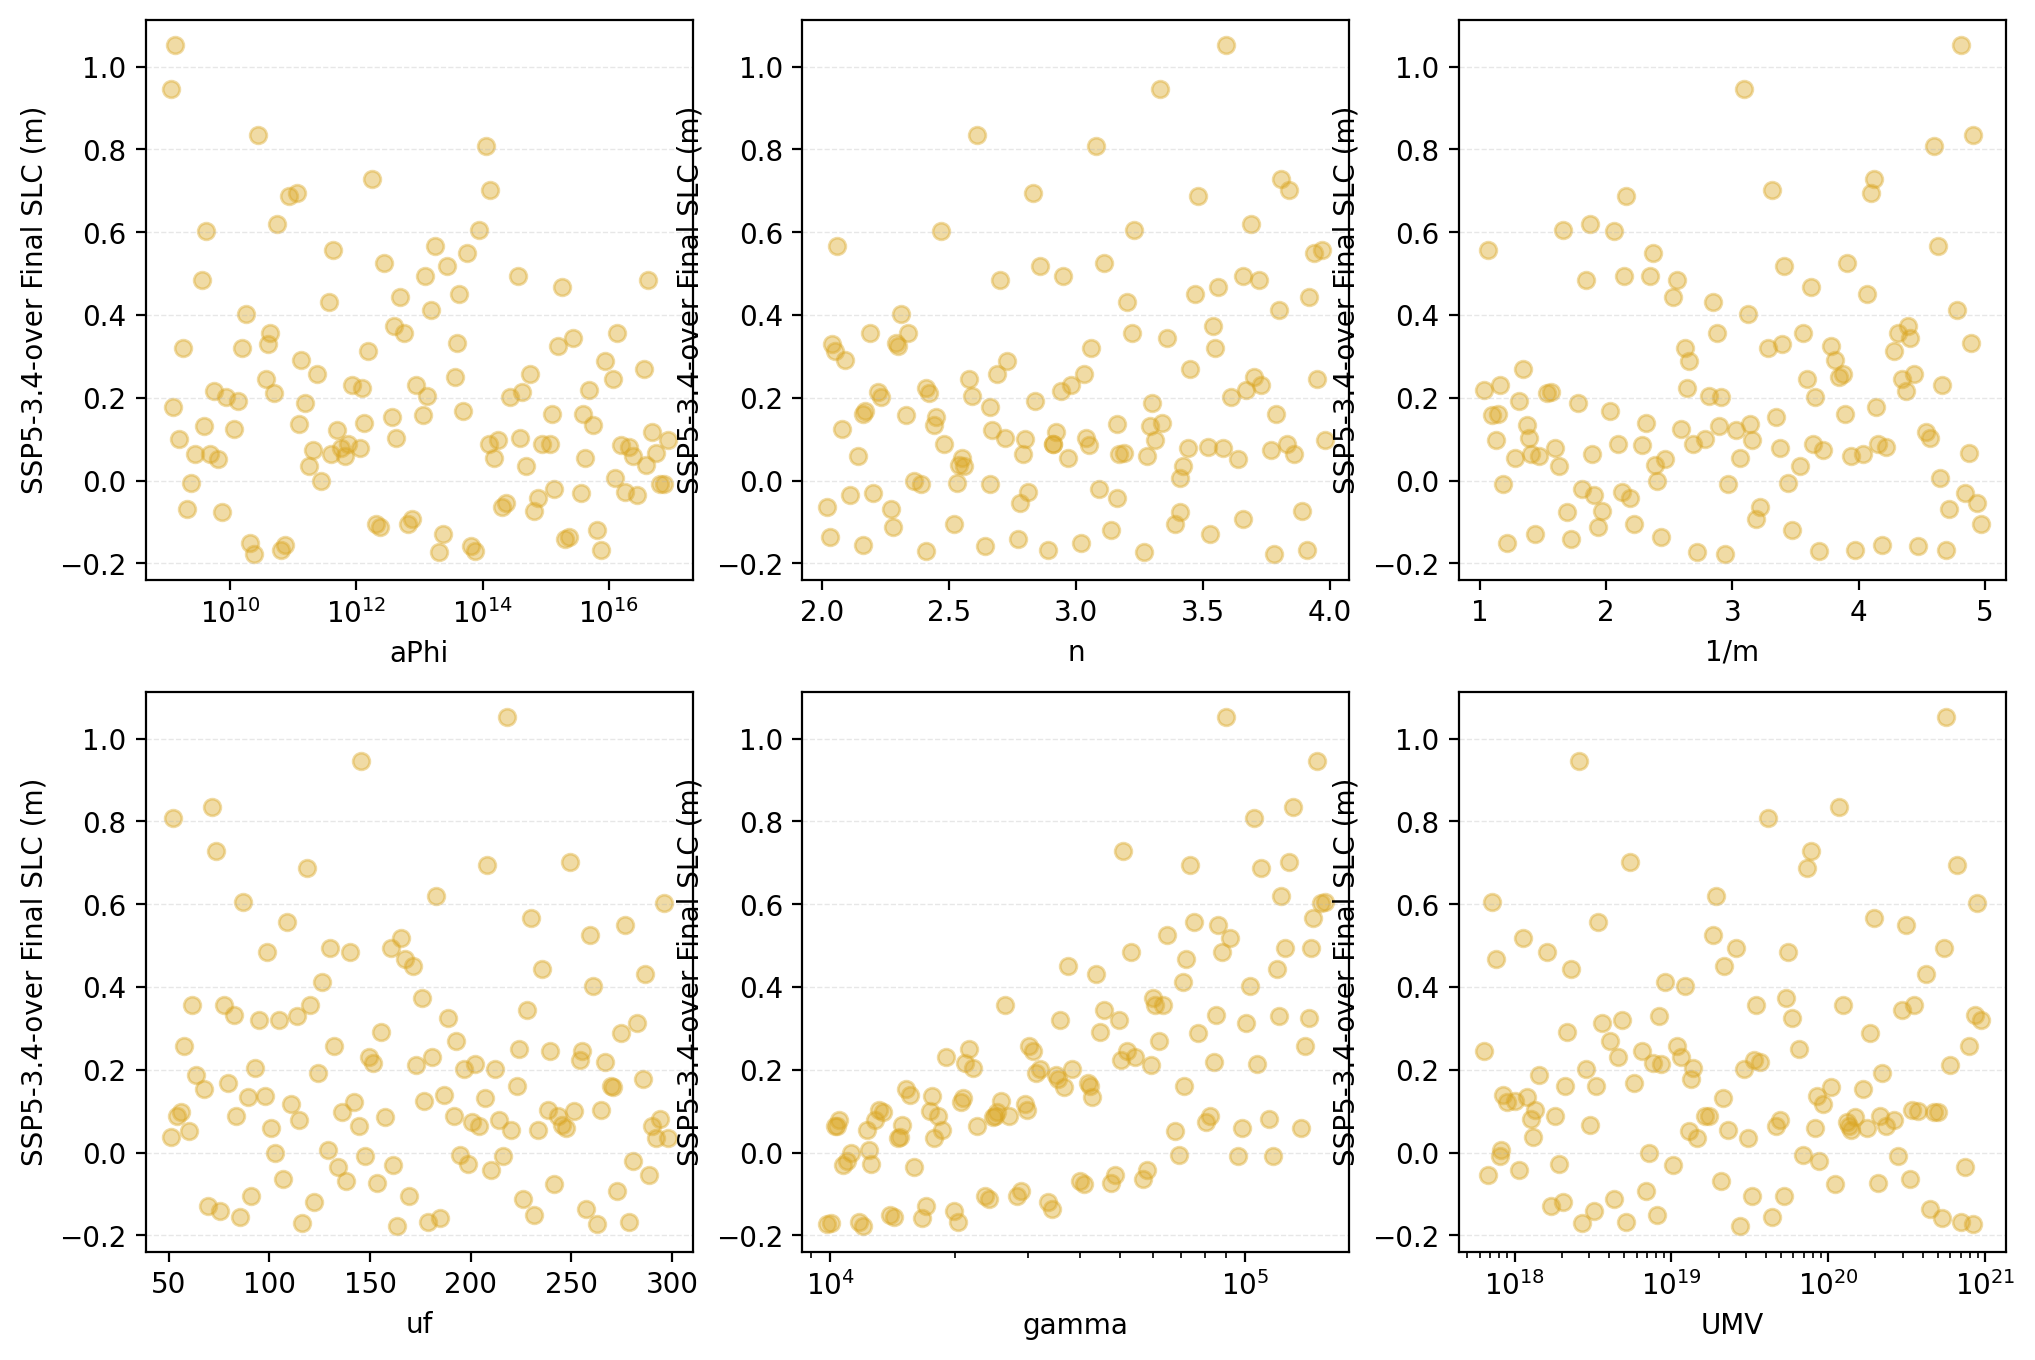

In [54]:
p_names = ['aPhi', 'n', '1/m', 'uf', 'gamma', 'UMV']
scenario = final_534
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8), dpi=200)
axes = axes.flatten()
for i, p_name in enumerate(p_names):
    ax = axes[i]
    p_values = params[p_name].values
    ax.scatter(p_values, scenario, alpha=0.4, color='goldenrod')
    ax.set_xlabel(p_name)
    ax.set_ylabel('SSP5-3.4-over Final SLC (m)')
    ax.grid(visible=True, which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.3)

for i in [0, 4, 5]:
    axes[i].set_xscale('log')

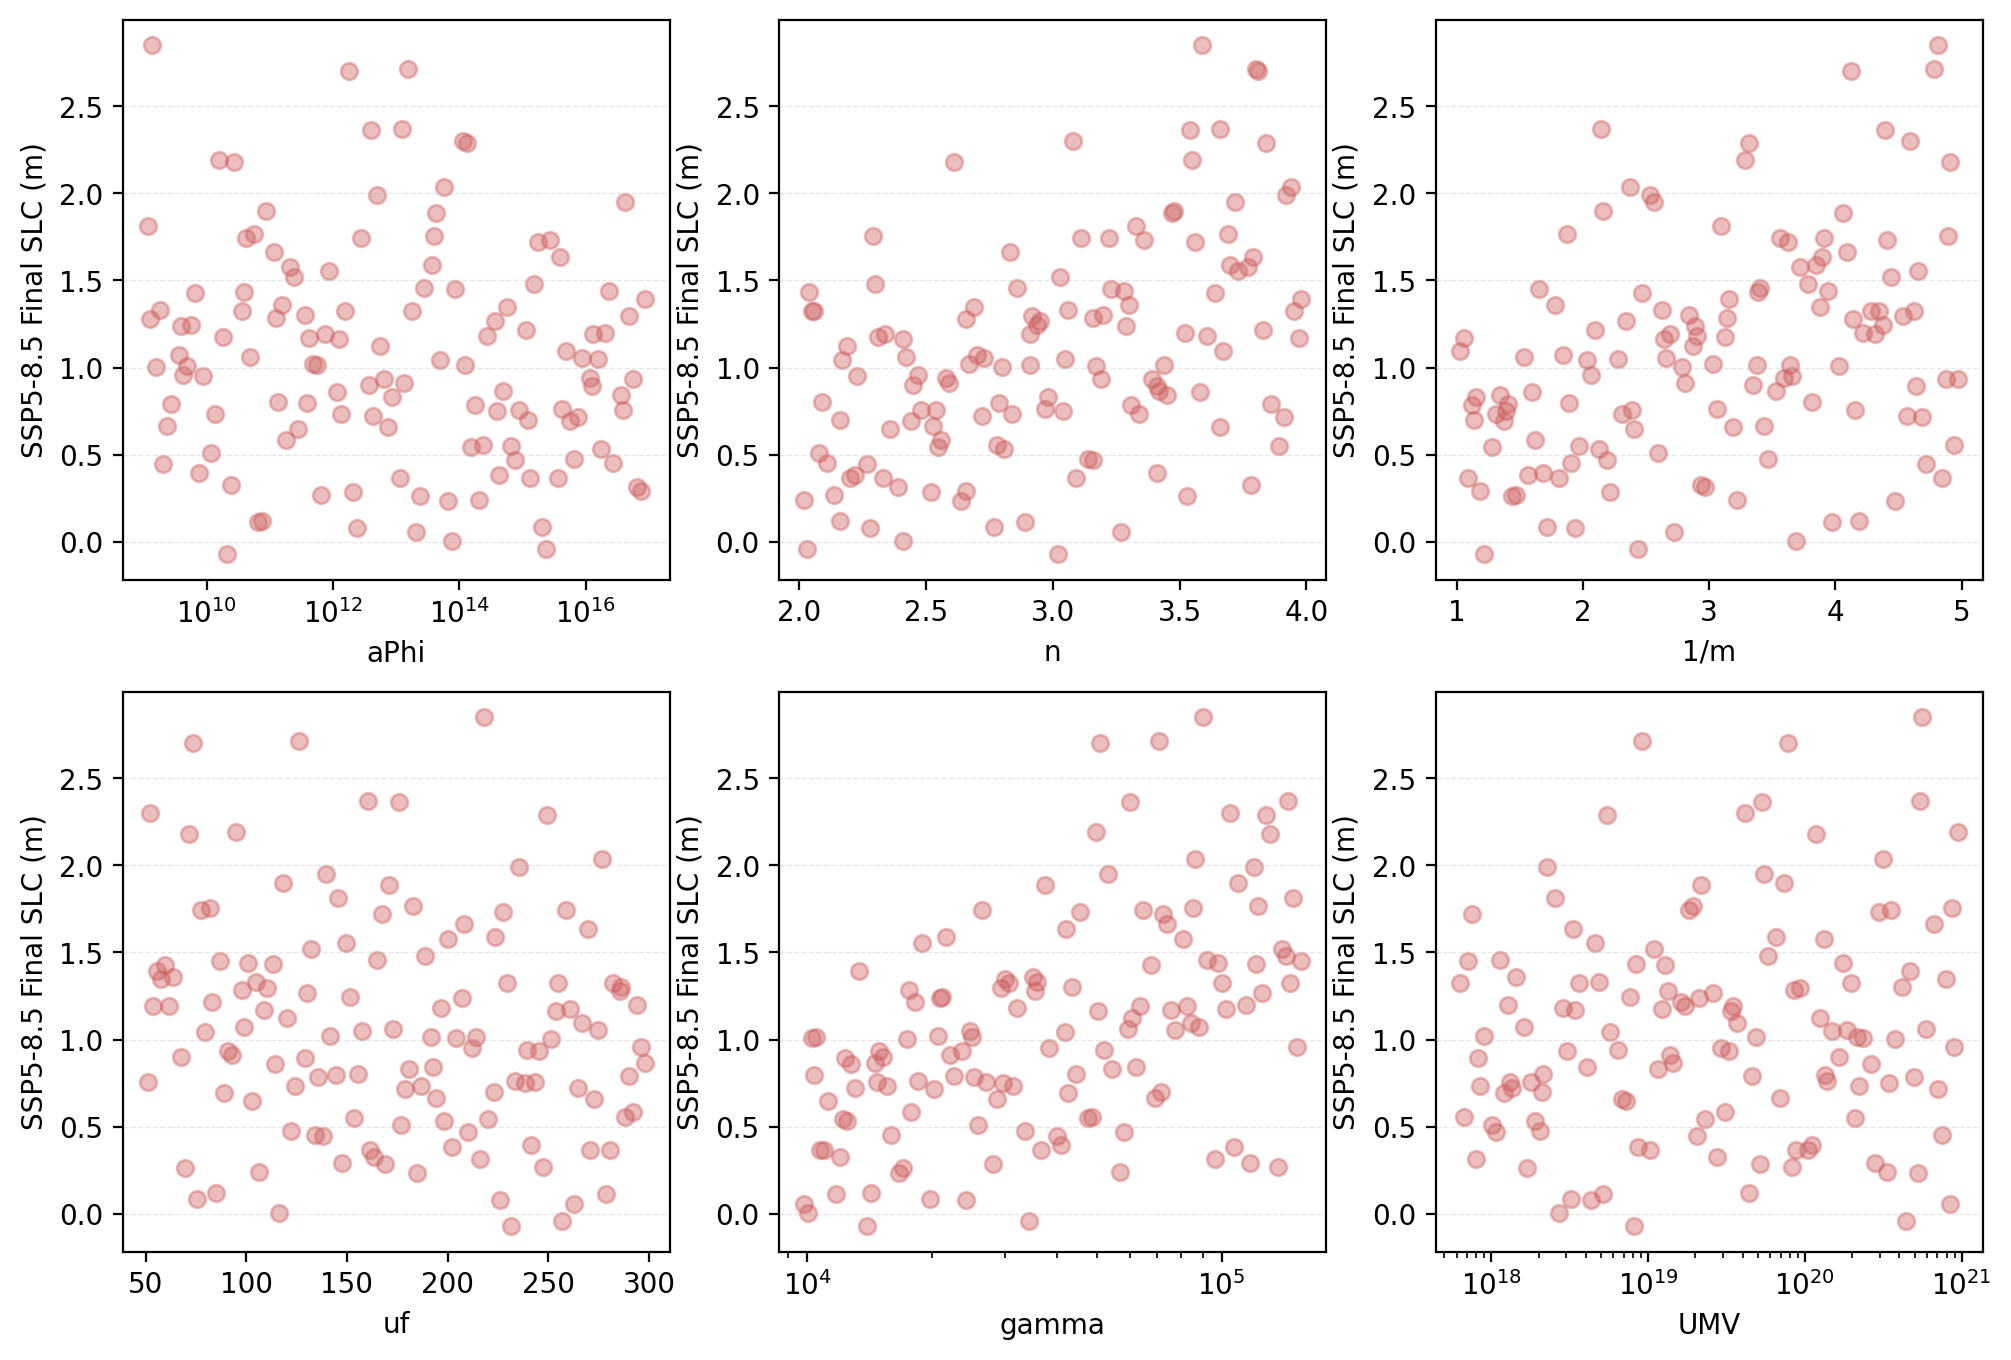

In [55]:
p_names = ['aPhi', 'n', '1/m', 'uf', 'gamma', 'UMV']
scenario = final_585
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8), dpi=200)
axes = axes.flatten()
for i, p_name in enumerate(p_names):
    ax = axes[i]
    p_values = params[p_name].values
    ax.scatter(p_values, scenario, alpha=0.4, color='indianred')
    ax.set_xlabel(p_name)
    ax.set_ylabel('SSP5-8.5 Final SLC (m)')
    ax.grid(visible=True, which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.3)

for i in [0, 4, 5]:
    axes[i].set_xscale('log')

In [32]:
from collections import defaultdict
from pathlib import Path
models = ['CESM2-WACCM', 'MRI-ESM2-0', 'EC-Earth3-Veg', 'MIROC-ES2L']
smb_path = Path('/Volumes/LaCie/smb/smb')
cmip_path = Path()
temperature = defaultdict(dict)
warming = defaultdict(dict)
for model in models:
    print(model)
    for scenario in scenarios:
        print(f"    {scenario}")
        file = smb_path / scenario / f'smb_{model}_{scenario}_8km.nc'
        ds = xr.open_dataset(file)
        init_temp = ds['tas'].isel(time=0).mean(dim=['x', 'y']).values
        final_temp = ds['tas'].isel(time=-1).mean(dim=['x', 'y']).values
        temperature[model][scenario] = final_temp
        warming[model][scenario] = final_temp - init_temp

CESM2-WACCM
    ssp126
    ssp534-over
    ssp585
MRI-ESM2-0
    ssp126
    ssp534-over
    ssp585
EC-Earth3-Veg
    ssp126
    ssp534-over
    ssp585
MIROC-ES2L
    ssp126
    ssp534-over
    ssp585


In [ ]:
from pathlib import Path
from collections import defaultdict
from xarray.coders import CFDatetimeCoder
coder = CFDatetimeCoder(use_cftime=True)

tfdepth = '0010'
tf_path = Path("/Volumes/LaCie/thermal_forcing")
tf_anom = defaultdict(dict)
for scenario in scenarios:
    print(scenario)
    for model in models:
        print(f"    {model}")
        modeldir = tf_path / scenario / model
        initfile = modeldir / f'thermal_forcing_{model}_{scenario}_8km_2007.nc'
        endfile = modeldir / f'thermal_forcing_{model}_{scenario}_8km_2300.nc'
        with xr.open_dataset(initfile, decode_times=coder) as file:
            init = file[f'thermal_forcing_{tfdepth}'].mean(dim=['x', 'y']).values
        with xr.open_dataset(endfile, decode_times=coder) as file:
            end = file[f'thermal_forcing_{tfdepth}'].mean(dim=['x', 'y']).values
        tf_anom[scenario][model] = end - init

ssp126
    CESM2-WACCM
    MRI-ESM2-0
    EC-Earth3-Veg
    MIROC-ES2L
ssp534-over
    CESM2-WACCM
    MRI-ESM2-0
    EC-Earth3-Veg
    MIROC-ES2L
ssp585
    CESM2-WACCM
    MRI-ESM2-0
    EC-Earth3-Veg
    MIROC-ES2L


In [50]:
from pathlib import Path
from collections import defaultdict
from xarray.coders import CFDatetimeCoder
coder = CFDatetimeCoder(use_cftime=True)

smb_path = Path("/Volumes/LaCie/smb/smb_anomaly_timeseries_antarctic_mask")
smb_anom = defaultdict(dict)
for scenario in scenarios:
    print(scenario)
    for model in models:
        print(f"    {model}")
        modeldir = smb_path / scenario
        file = modeldir / f'smb_anomaly_{model}_{scenario}_timeseries.nc'
        with xr.open_dataset(file, decode_times=coder) as file:
            smb = file.smb_anomaly
            anom = smb.isel(time=-1) - smb.sel(time=2007)
        smb_anom[scenario][model] = anom

ssp126
    CESM2-WACCM
    MRI-ESM2-0
    EC-Earth3-Veg
    MIROC-ES2L
ssp534-over
    CESM2-WACCM
    MRI-ESM2-0
    EC-Earth3-Veg
    MIROC-ES2L
ssp585
    CESM2-WACCM
    MRI-ESM2-0
    EC-Earth3-Veg
    MIROC-ES2L


In [31]:
tf_anom_df = pd.DataFrame(tf_anom).T
tf_anom_df

,CESM2-WACCM,MRI-ESM2-0,EC-Earth3-Veg,MIROC-ES2L
ssp126,0.496851,0.175701,0.524968,0.125393
ssp534-over,0.535232,0.208487,0.686478,0.145749
ssp585,2.999207,1.785979,3.394956,2.445223


In [34]:
center = {'CESM2-WACCM': 'NCAR', 'MRI-ESM2-0': 'MRI', 'EC-Earth3-Veg': 'EC-Earth-Consortium', 'MIROC-ES2L': 'MIROC'}
grid = {'CESM2-WACCM': 'gn', 'MRI-ESM2-0': 'gn', 'EC-Earth3-Veg': 'gr', 'MIROC-ES2L': 'gn'}
realisation = {'CESM2-WACCM': 'r1i1p1f1', 'MRI-ESM2-0': 'r1i1p1f1', 'EC-Earth3-Veg': 'r1i1p1f1', 'MIROC-ES2L': 'r1i1p1f2'}

cmip_path = Path('/Volumes/LaCie/CMIP6')
historical_dir = cmip_path / 'CMIP'
historical_temp = {}
for model in models:
    center_name = center[model]
    grid_name = grid[model]
    real = realisation[model]
    datadir = historical_dir / center_name / model / 'historical' / real / 'Amon' / 'tas' / grid_name
    version = datadir / list(datadir.glob('*'))[0]
    files = sorted(version.glob('tas_*.nc'))
    ds = xr.open_mfdataset(files)
    historical = ds.sel(time=slice('1850-01-01', '1899-12-31'))
    hist_temp = historical['tas'].mean(dim=['time', 'lat', 'lon']).values
    historical_temp[model] = hist_temp

In [35]:
import warnings
from xarray import SerializationWarning
warnings.filterwarnings("ignore", category=SerializationWarning)

scenario_dir = cmip_path / 'ScenarioMIP'
cmip_temp = defaultdict(dict)
cmip_warming = defaultdict(dict)
for model in models:
    for scenario in scenarios:
        datadir = scenario_dir / center[model] / model / scenario / realisation[model] / 'Amon' / 'tas' / grid[model]
        version = datadir / list(datadir.glob('*'))[0]
        files = sorted(version.glob('*.nc'))
        finalfile = xr.open_dataset(files[-1])
        final_temp = finalfile['tas'].isel(time=-1).mean(dim=['lat', 'lon']).values
        cmip_temp[model][scenario] = final_temp
        cmip_warming[model][scenario] = final_temp - historical_temp[model]

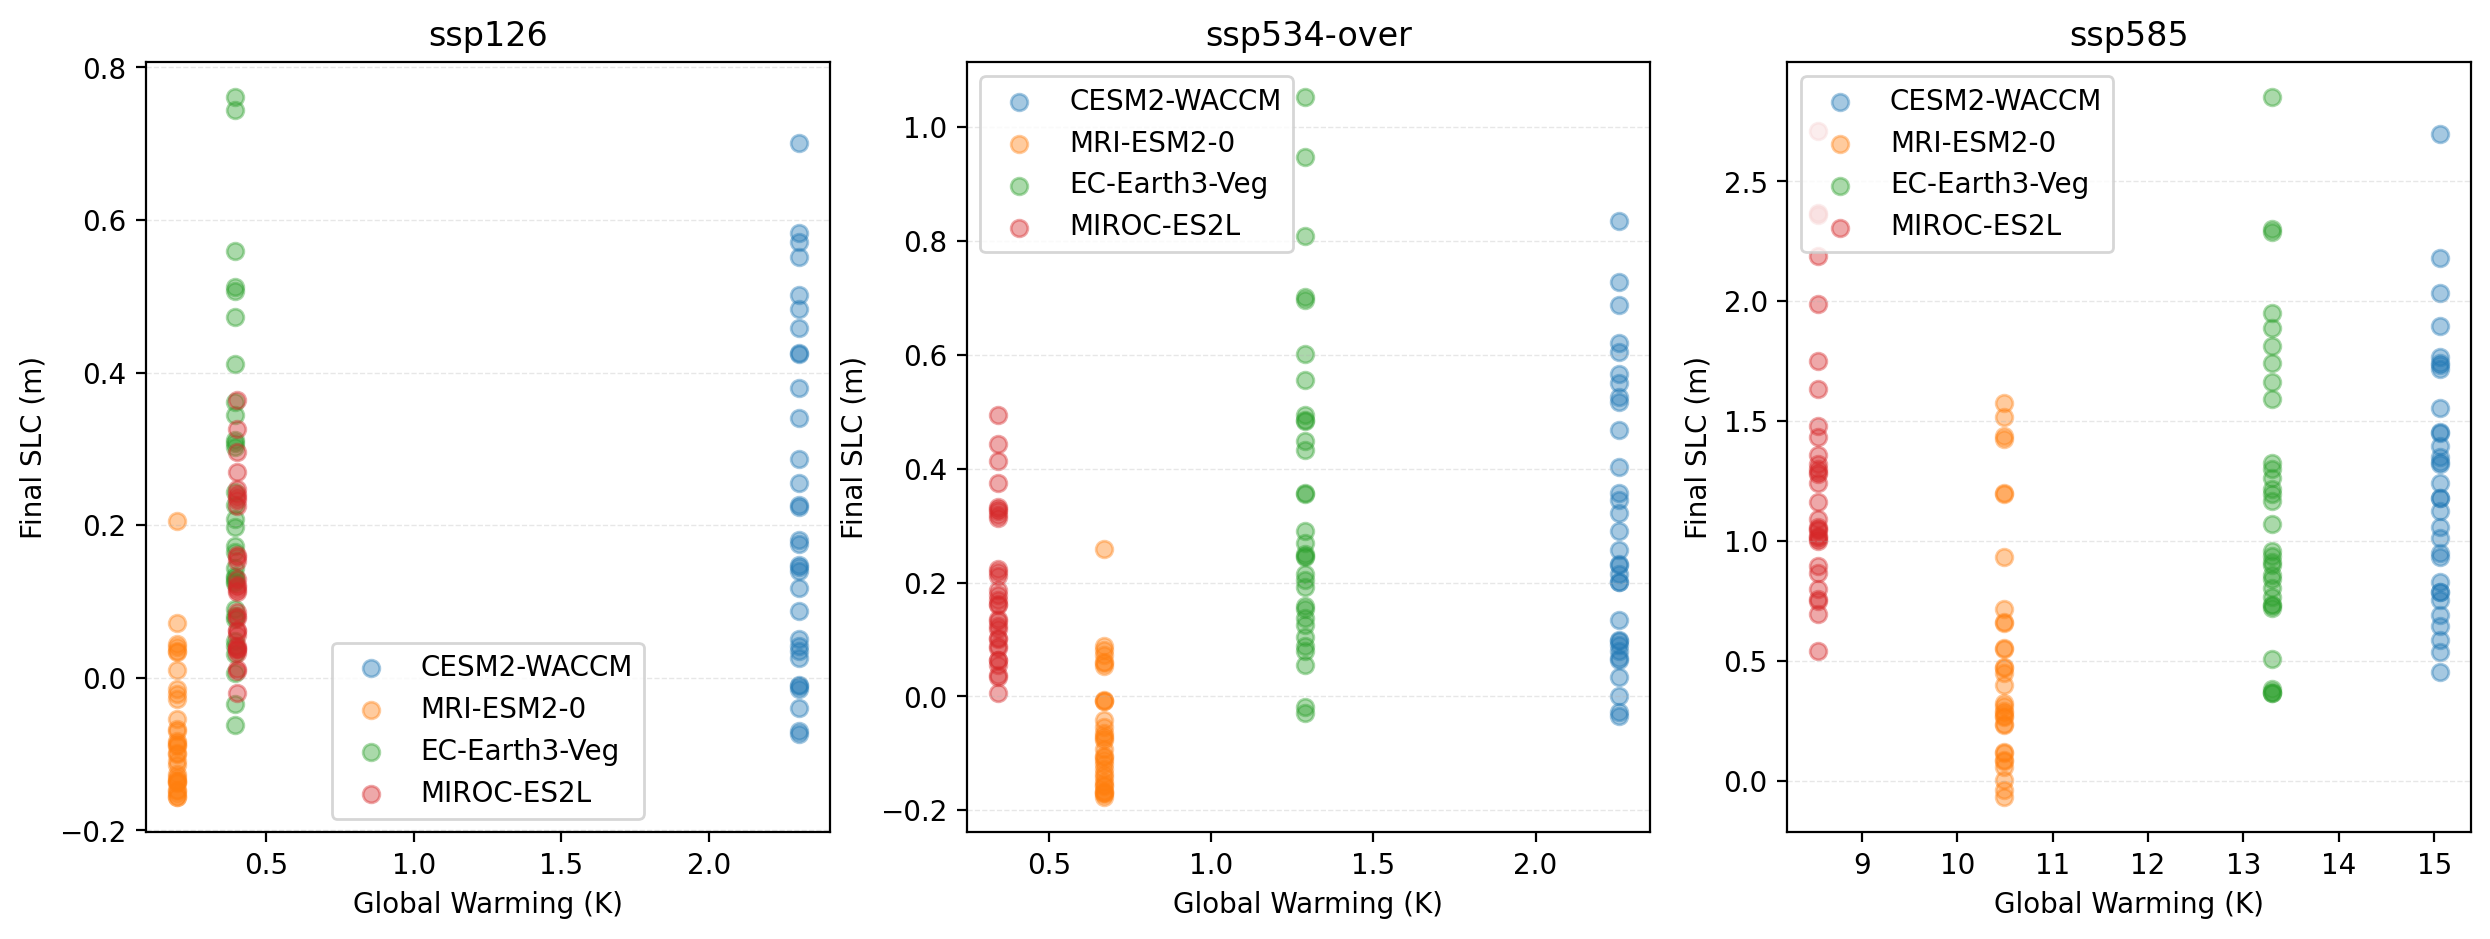

In [36]:
fig, axes = plt.subplots(ncols=3, figsize=(15, 5), dpi=200)
axes = axes.flatten()
for ax, scenario in zip(axes, scenarios):
    final_sle = data[scenario].isel(time=-1).values    
    for model in models:
        model_indices = params[params['model'] == model].index
        model_sle = final_sle[model_indices]
        temp = cmip_warming[model][scenario]
        ax.scatter([temp]*len(model_sle), model_sle, alpha=0.4, label=model)
    ax.set_title(scenario)
    ax.set_xlabel('Global Warming (K)')
    ax.set_ylabel('Final SLC (m)')
    ax.grid(visible=True, which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.3)
    ax.legend()


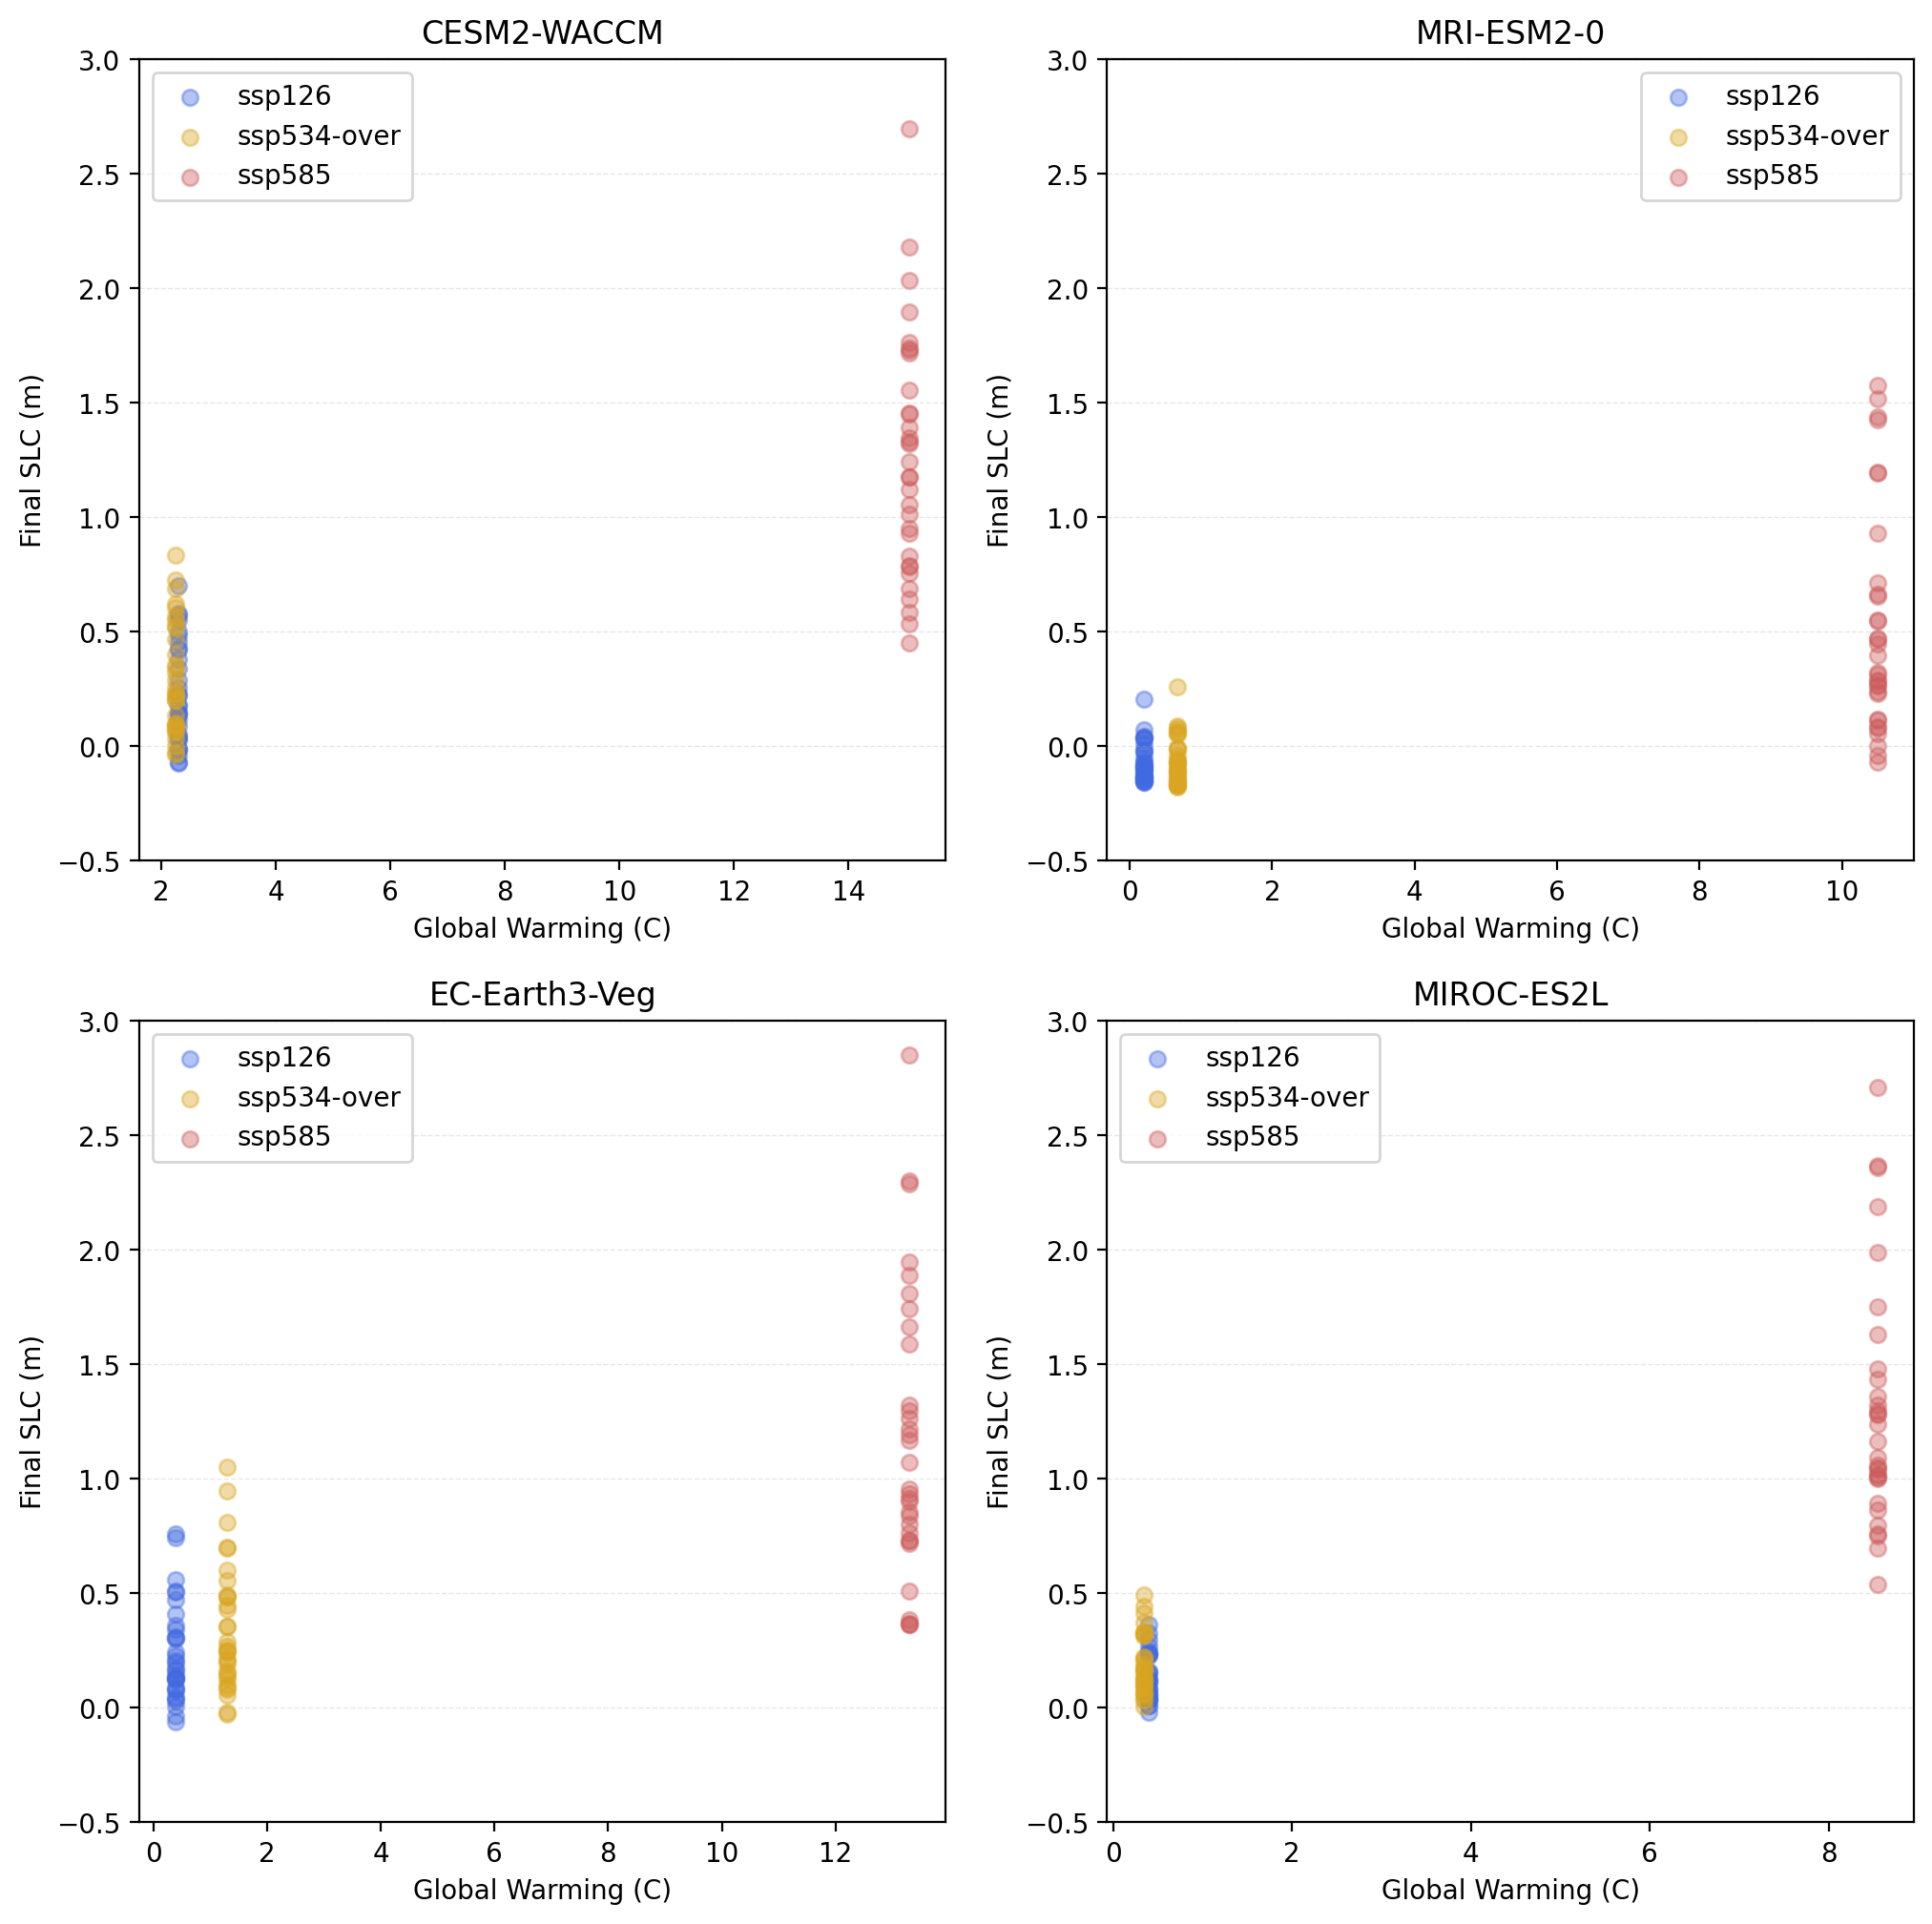

In [37]:
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(12, 12), dpi=200)
axes = axes.flatten()
for ax, model in zip(axes, models):
    for scenario in scenarios:
        final_sle = data[scenario].isel(time=-1).values
        model_indices = params[params['model'] == model].index
        model_sle = final_sle[model_indices]
        temp = cmip_warming[model][scenario]
        ax.scatter([temp]*len(model_sle), model_sle, alpha=0.4, label=scenario, color=colors[scenario])
    ax.set_title(model)
    ax.set_xlabel('Global Warming (C)')
    ax.set_ylabel('Final SLC (m)')
    ax.grid(visible=True, which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.3)
    ax.legend()
    ax.set_ylim(-0.5, 3)
plt.show()

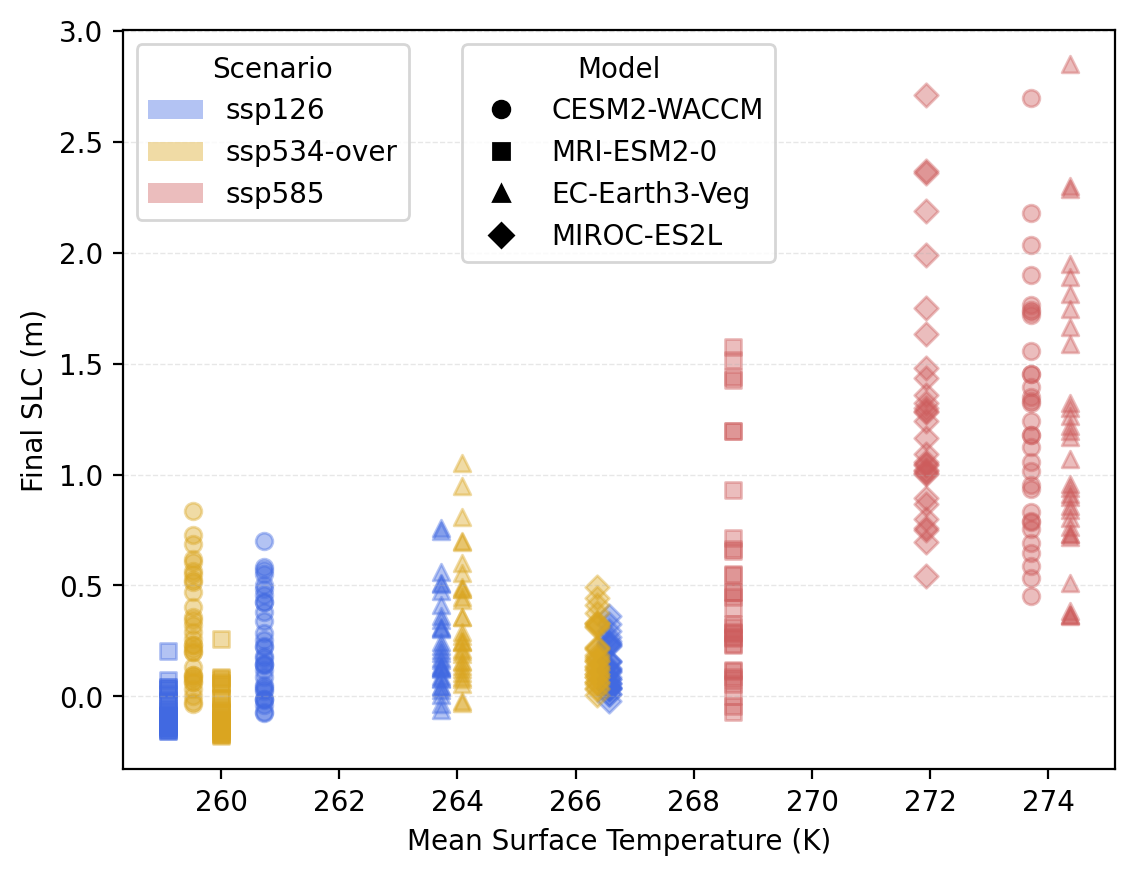

In [38]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
fig, ax = plt.subplots(dpi=200)
marker = {'CESM2-WACCM': 'o', 'MRI-ESM2-0': 's', 'EC-Earth3-Veg': '^', 'MIROC-ES2L': 'D'}
colors = {'ssp126': 'royalblue', 'ssp534-over': 'goldenrod', 'ssp585': 'indianred'}
for scenario in scenarios:
    for model in models:
        final_sle = data[scenario].isel(time=-1).values
        model_indices = params[params['model'] == model].index
        model_sle = final_sle[model_indices]
        temp = temperature[model][scenario]
        ax.scatter([temp]*len(model_sle), model_sle, alpha=0.4, marker=marker[model], color=colors[scenario])
ax.set_xlabel('Mean Surface Temperature (K)')
ax.set_ylabel('Final SLC (m)')
ax.grid(visible=True, which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.3)

model_handles = [
    Line2D(
        [], [], linestyle='',
        marker=marker[m],
        color='k',
        label=m
    )
    for m in marker
]

legend_models = ax.legend(
    handles=model_handles,
    title='Model',
    loc='upper center'
)
ax.add_artist(legend_models)

scenario_handles = [
    Patch(
        facecolor=colors[s],
        edgecolor='None',
        alpha=0.4,
        label=s
    )
    for s in colors
]

ax.legend(
    handles=scenario_handles,
    title='Scenario',
    loc='upper left'
)


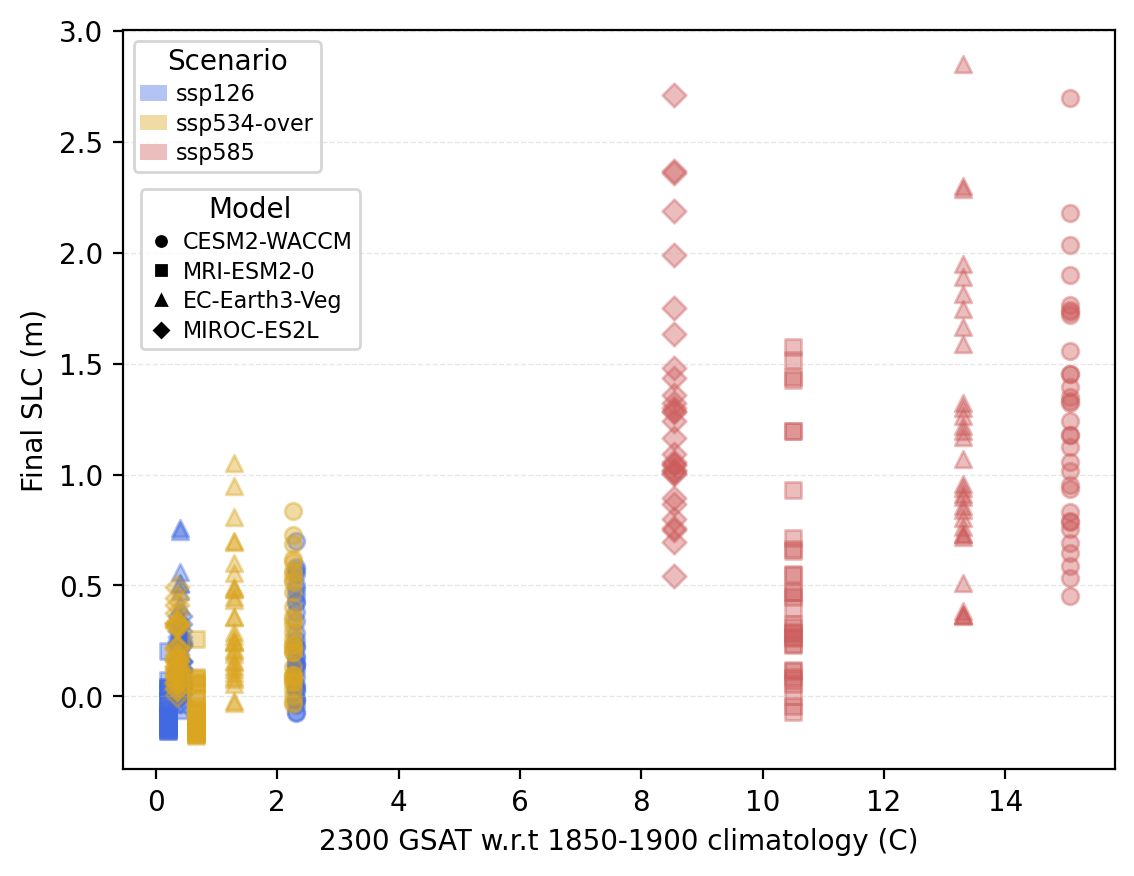

In [39]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, ax = plt.subplots(dpi=200)
marker = {'CESM2-WACCM': 'o', 'MRI-ESM2-0': 's', 'EC-Earth3-Veg': '^', 'MIROC-ES2L': 'D'}
colors = {'ssp126': 'royalblue', 'ssp534-over': 'goldenrod', 'ssp585': 'indianred'}
for scenario in scenarios:
    for model in models:
        final_sle = data[scenario].isel(time=-1).values
        model_indices = params[params['model'] == model].index
        model_sle = final_sle[model_indices]
        temp = cmip_warming[model][scenario]
        ax.scatter([temp]*len(model_sle), model_sle, alpha=0.4, marker=marker[model], color=colors[scenario])
ax.set_xlabel('2300 GSAT w.r.t 1850-1900 climatology (C)')
ax.set_ylabel('Final SLC (m)')
ax.grid(visible=True, which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.3)

model_handles = [
    Line2D(
        [], [], linestyle='',
        marker=marker[m],
        color='k',
        label=m
    )
    for m in marker
]

legend_models = ax.legend(
    handles=model_handles,
    title='Model',
    bbox_to_anchor=(0.25, 0.8),
    fontsize=8,
    markerscale=0.6,
    labelspacing=0.3,
    handlelength=1.2,
    handletextpad=0.4,
    borderpad=0.3
)
ax.add_artist(legend_models)

scenario_handles = [
    Patch(
        facecolor=colors[s],
        edgecolor='None',
        alpha=0.4,
        label=s
    )
    for s in colors
]

ax.legend(
    handles=scenario_handles,
    title='Scenario',
    loc='upper left',
    fontsize=8,
    markerscale=0.6,
    labelspacing=0.3,
    handlelength=1.2,
    handletextpad=0.4,
    borderpad=0.3
)


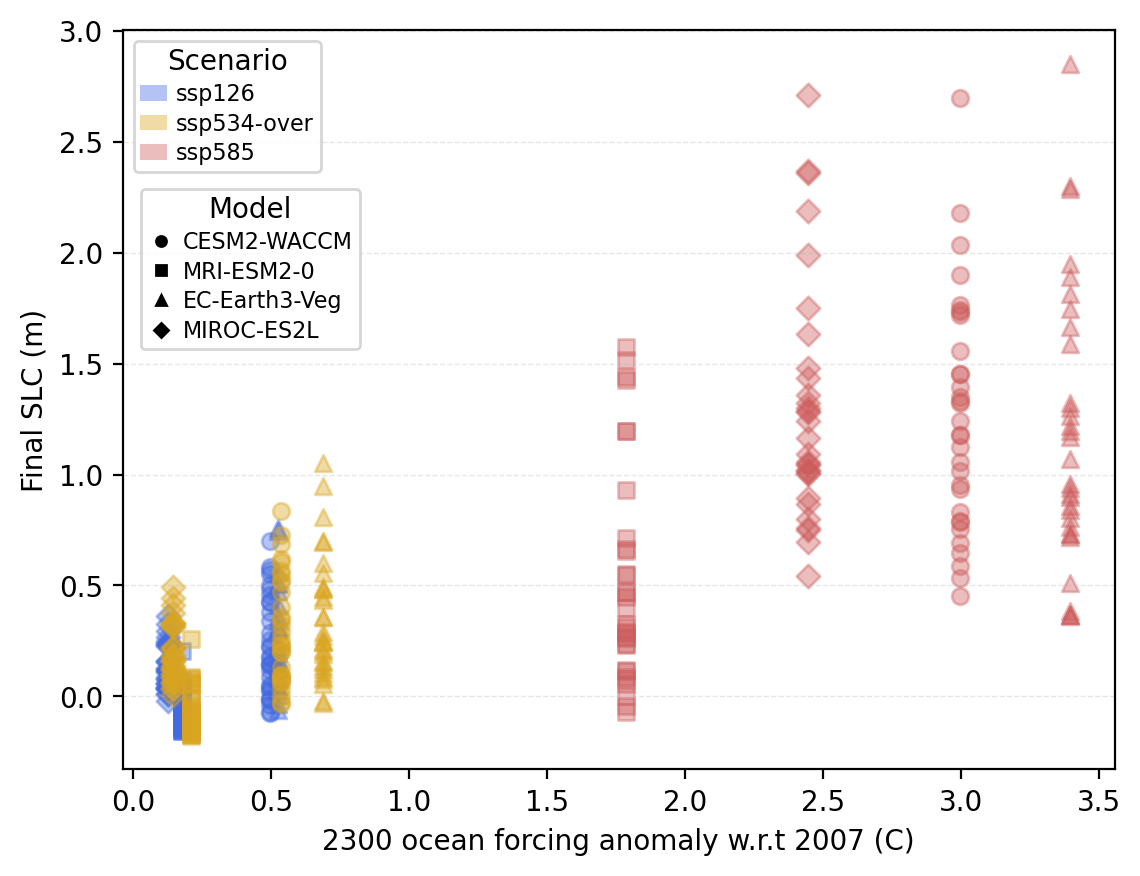

In [41]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, ax = plt.subplots(dpi=200)
marker = {'CESM2-WACCM': 'o', 'MRI-ESM2-0': 's', 'EC-Earth3-Veg': '^', 'MIROC-ES2L': 'D'}
colors = {'ssp126': 'royalblue', 'ssp534-over': 'goldenrod', 'ssp585': 'indianred'}
for scenario in scenarios:
    for model in models:
        final_sle = data[scenario].isel(time=-1).values
        model_indices = params[params['model'] == model].index
        model_sle = final_sle[model_indices]
        temp = tf_anom[scenario][model]
        ax.scatter([temp]*len(model_sle), model_sle, alpha=0.4, marker=marker[model], color=colors[scenario])
ax.set_xlabel('2300 ocean forcing anomaly w.r.t 2007 (C)')
ax.set_ylabel('Final SLC (m)')
ax.grid(visible=True, which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.3)

model_handles = [
    Line2D(
        [], [], linestyle='',
        marker=marker[m],
        color='k',
        label=m
    )
    for m in marker
]

legend_models = ax.legend(
    handles=model_handles,
    title='Model',
    bbox_to_anchor=(0.25, 0.8),
    fontsize=8,
    markerscale=0.6,
    labelspacing=0.3,
    handlelength=1.2,
    handletextpad=0.4,
    borderpad=0.3
)
ax.add_artist(legend_models)

scenario_handles = [
    Patch(
        facecolor=colors[s],
        edgecolor='None',
        alpha=0.4,
        label=s
    )
    for s in colors
]

ax.legend(
    handles=scenario_handles,
    title='Scenario',
    loc='upper left',
    fontsize=8,
    markerscale=0.6,
    labelspacing=0.3,
    handlelength=1.2,
    handletextpad=0.4,
    borderpad=0.3
)


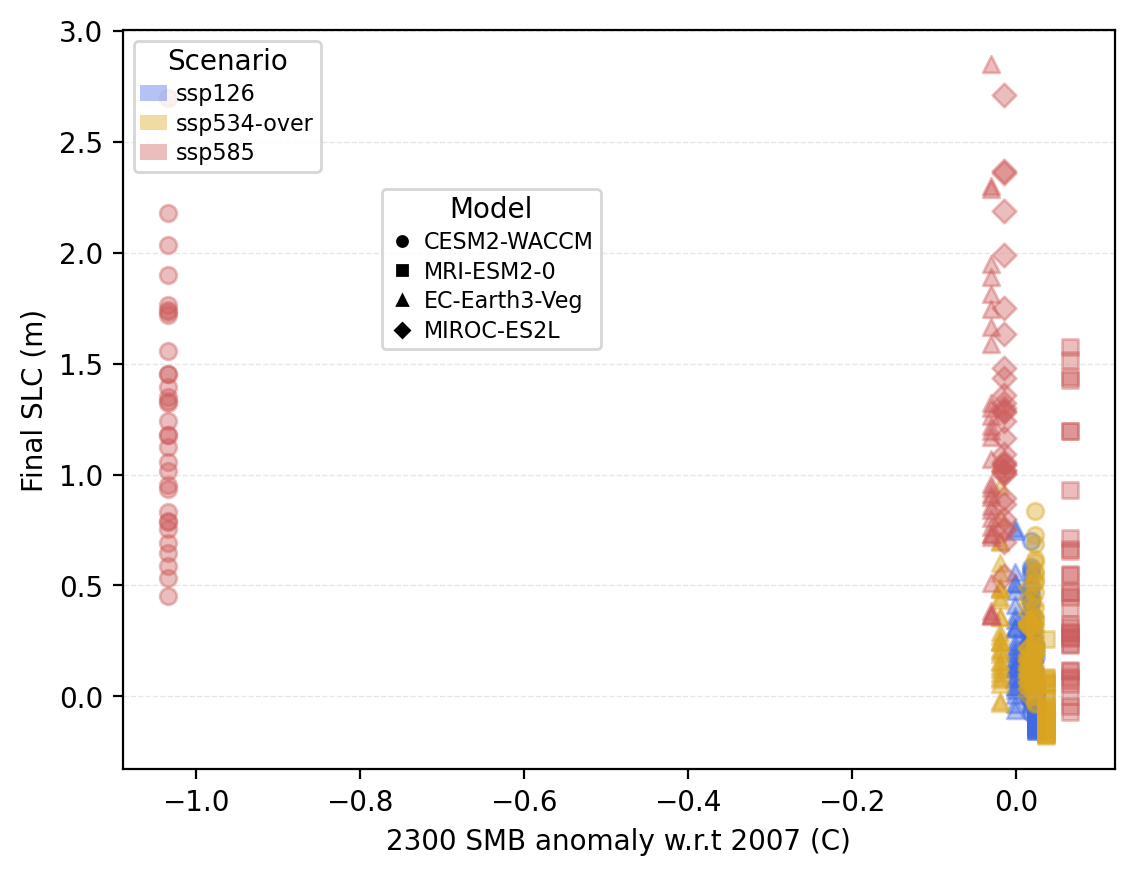

In [51]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, ax = plt.subplots(dpi=200)
marker = {'CESM2-WACCM': 'o', 'MRI-ESM2-0': 's', 'EC-Earth3-Veg': '^', 'MIROC-ES2L': 'D'}
colors = {'ssp126': 'royalblue', 'ssp534-over': 'goldenrod', 'ssp585': 'indianred'}
for scenario in scenarios:
    for model in models:
        final_sle = data[scenario].isel(time=-1).values
        model_indices = params[params['model'] == model].index
        model_sle = final_sle[model_indices]
        temp = smb_anom[scenario][model]
        ax.scatter([temp]*len(model_sle), model_sle, alpha=0.4, marker=marker[model], color=colors[scenario])
ax.set_xlabel('2300 SMB anomaly w.r.t 2007 (C)')
ax.set_ylabel('Final SLC (m)')
ax.grid(visible=True, which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.3)

model_handles = [
    Line2D(
        [], [], linestyle='',
        marker=marker[m],
        color='k',
        label=m
    )
    for m in marker
]

legend_models = ax.legend(
    handles=model_handles,
    title='Model',
    bbox_to_anchor=(0.25, 0.8),
    fontsize=8,
    markerscale=0.6,
    labelspacing=0.3,
    handlelength=1.2,
    handletextpad=0.4,
    borderpad=0.3
)
ax.add_artist(legend_models)

scenario_handles = [
    Patch(
        facecolor=colors[s],
        edgecolor='None',
        alpha=0.4,
        label=s
    )
    for s in colors
]

ax.legend(
    handles=scenario_handles,
    title='Scenario',
    loc='upper left',
    fontsize=8,
    markerscale=0.6,
    labelspacing=0.3,
    handlelength=1.2,
    handletextpad=0.4,
    borderpad=0.3
)


In [57]:
maxrun = 128
df = params[['model']+p_names]
df = df[:maxrun]
df['ssp126'] = final_126
df['ssp534-over'] = final_534
df['ssp585'] = final_585
df = df.rename(columns={'1/m': 'm'})

df_long = df.melt(
    id_vars=['model', 'aPhi', 'n', 'm', 'uf', 'gamma', 'UMV'],
    value_vars=['ssp126', 'ssp534-over', 'ssp585'],
    var_name='scenario',
    value_name='sle'
)

df_long['warming'] = df_long.apply(
    lambda r: cmip_warming[r['model']][r['scenario']],
    axis=1
)
df_long['thermal_forcing'] = df_long.apply(lambda r: tf_anom[r['scenario']][r['model']], axis=1)

df_long.to_csv('R/emulator_inputs_2300_sle.csv', index=False)

In [259]:
df_long

,model,aPhi,n,m,uf,gamma,UMV,scenario,sle,warming
0,CESM2-WACCM,5.620000e+09,2.94,4.375000,151.6,21179,7.690000e+18,ssp126,0.117237,2.305481
1,CESM2-WACCM,5.620000e+13,3.94,2.375000,276.6,86159,3.140000e+20,ssp126,0.458038,2.305481
2,CESM2-WACCM,5.620000e+15,2.44,1.375000,89.1,42717,1.200000e+18,ssp126,0.087717,2.305481
3,CESM2-WACCM,5.620000e+11,3.44,3.375000,214.1,10501,4.910000e+19,ssp126,-0.011318,2.305481
4,CESM2-WACCM,5.620000e+12,2.19,2.875000,120.3,60667,1.240000e+20,ssp126,0.287315,2.305481
...,...,...,...,...,...,...,...,...,...,...
379,MIROC-ES2L,3.920000e+12,3.54,4.390625,176.0,60006,5.360000e+19,ssp585,2.360865,8.543518
380,MIROC-ES2L,3.920000e+11,2.79,1.890625,144.7,10386,1.350000e+20,ssp585,0.797945,8.543518
381,MIROC-ES2L,3.920000e+15,3.79,3.890625,269.7,42252,3.320000e+18,ssp585,1.632340,8.543518
382,MIROC-ES2L,3.920000e+13,2.29,4.890625,82.2,85220,8.650000e+20,ssp585,1.751833,8.543518
